# Comparing conformal EoSs to prior

In [3]:
# Ensuring it's running in correct working directory
import os
os.chdir("/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/executables/")

import gaussian_process

import h5py 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.interpolate as interpolate
import scipy.integrate as integrate
import scipy.stats
from scipy.stats import uniform, loguniform

import sys
sys.path.append("/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter")
import utils
from utils import clean_conditioning
from utils import meraki

# import temperance as tmpy
# import temperance.core.result as result
# from temperance.core.result import EoSPosterior
# from temperance.sampling import eos_prior

import tqdm
import shutil    # For creating copies of outfiles
from pathlib import Path    # For creating new directories for outfile copies

/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/executables/TOVSolver.py:18: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [4]:
# default_prior_set = eos_prior.EoSPriorSet.get_default()

### Nucleon mass in grams
mass_of_nucleon = 1/(6.02 * 10**23)
### Nucleon mass in MeV/c2
nucleon_mass_in_MeV = 939
### Conversion factors for Mev,fm to CGS units
gcm3_to_dynecm2=8.9875e20 
MeV_to_gcm3 = 1.7827e12 
dynecm2_to_MeVFermi = 1.6022e33
gcm3_to_fm4 = 3.5178e14

fm_in_cgs = 1e-13
rho_nuc_in_cgs = .16 * mass_of_nucleon / (fm_in_cgs)**3

default_hyperparameters = {"gamma_low":.1, "gamma_high":1.5,
                           "alpha_low":.1, "alpha_high":5.,
                           "corr_len_low":1e-3, "corr_len_high":1e1}

## Functions for generating prior

In [3]:
def white_noise(sigma, tabulation_points):
    wn_matrix = ((sigma)**2)*np.identity(len(tabulation_points))
    return wn_matrix

In [4]:
def rbf(gamma, corr_len, tabulation_points):
    """ 
    A function to calculate elements of a covariance kernel matrix using the radial basis
    (squared exponential) covariance function.
    
    Input: n-dimensional tabulation points for GPR, a correlation strength factor gamma,
    and correlation length scale parameter.
    
    Returns: nxn matrix containing covariance values according to squared exponential kernel. 
    """
    ### Need to convert densities to be in log for scaling factors
    ### (Assuming tabulation points are densities in cgs units)
    logrho = np.log(tabulation_points)
    sqexpo = lambda x, x_prime: gamma * np.exp(-(((np.linalg.norm([x - x_prime]))**2)/(2*(corr_len**2))))
    K = np.empty((len(tabulation_points), len(tabulation_points)))
    for i, dens in enumerate(logrho):
        for j, dens_prime in enumerate(logrho):
            K[i,j] = sqexpo(dens, dens_prime)
    return K                                             

In [5]:
def rqf(gamma, alpha, corr_len, tabulation_points):
    """
    This function calculates the elements of a covariance matrix according to
    the rational quadratic covariance function. Using this kernel equates to using
    multiple squared exponential kernels, across multiple length scales. Much like
    the squared exponential kernel, the gamma parameter determines the overall strength
    of the correlation, and l corresponds to the characteristic length scale of these
    correlations. Lastly, alpha acts as a weight to each of the length scales. 
    
    Note: It is required for alpha and l > 0. 
    """
    logrho = np.log(tabulation_points)
    ratquad = lambda x, x_prime: (gamma**2)*((1. +  (((np.linalg.norm([x - x_prime], 2))**2)/(2*alpha*(corr_len**2))))**(-alpha))
    K = np.empty((len(tabulation_points), len(tabulation_points)))
    for i, dens in enumerate(logrho):
        for j, dens_prime in enumerate(logrho):
            K[i,j] = ratquad(dens, dens_prime)
    return K

In [6]:
def agn_collect_data(eos_dir, rho_vals_to_interp, tov_dir = ".", weights = False,
                     truncate_central = False, truncate_at_sat = False,
                     weight_columns = []):
    """
    Gather nuclear EoSs with equal weights for training the Gaussian Process.
    *Phase transitions may pose an issue.*
    """ 
    eos_path = f"{eos_dir}/eos_tables/" 
    eos_list = os.listdir(eos_path)
    data = np.zeros((len(eos_list), len(rho_vals_to_interp)))
    ### no need to sample according to weights --> use all
    if not weights:
        for i, eos in enumerate(eos_list):
            try:
                eos_data = pd.read_csv(f"{eos_path}/{eos}", header = 1, sep = r"\s+")
            except:
                raise KeyError(f"{eos} not found within directory. Available EoS's are: {eos_list}")
                
            if truncate_central:
                ### Truncate at central density corresponding to M_tov
                macros_file = f"{os.path.splitext(eos)[0]}.tab"
                eos_data = clean_conditioning.mtov_truncate(eos_dir,
                                                            macros_file,
                                                            eos_data) ### eos_data assumed to be a dataframe
            
            if truncate_at_sat: 
                ### Truncate after nuclear saturation density to ignore crust inhomogeneities
                ### BREAKS CONDITIONING. DUE TO MISSING VALUES WHERE INTERPOLANT SEARCHES FOR SOUND SPEED
                
                eos_data = eos_data[eos_data["n(fm-3)"] > 0.16] 
            
            phi_data = np.log(np.gradient(eos_data["rho(MeVfm-3)"],eos_data["P(MeVfm-3)"]) - 1.0)
            data[i,:] = interpolate.griddata(eos_data["n(fm-3)"]*mass_of_nucleon/fm_in_cgs**3, phi_data, rho_vals_to_interp)
            
            ### "Extend" nuclear training data interpolants to higher densities
            if any(np.isnan(x) for x in data[i,:]):
                idxs = np.where(np.isnan(data[i,:]))[0]
                if any(np.diff(idxs)) > 1: # check if missing points are close together
                    raise ValueError("Inconsistent sound speed detected.")
                elif all(np.diff(idxs)) == 1: # confirm NaN's are only at points past original interpolation range
                    causal_val = data[i,:][(np.where(np.isnan(data[i,:]))[0][0] - 1)]
                    data[i,:] = np.where(np.isnan(data[i,:]), causal_val, data[i,:]) # replace NaN's with phi based on last causal sound speed value
            
        return data

In [7]:
def get_consistent_metamodel(path="./eos_mm+chi+PSR/eos0.out", transition_density = rho_nuc_in_cgs):
    """
    Reinterpolate the metamodel to

    (1) Guarantee 1st law of thermodynmics consistency to a predictable precision
    (2) Guarantee there is a point where we need one for constructing the GP, and
    that the density of points is large enough for the sound speed calculation
    to be reliably carried out there.

    We also convert the table into cgs units.
    """
    # Constructing a metamodel with the boundary condition we need
    metamodel = pd.read_csv(path, names=["number_density", "energy_densityc2","pressure_nuclear"], sep = r"\s+", skiprows = 1)
    metamodel_cgs = pd.DataFrame({"baryon_density": np.array(metamodel["number_density"]) * mass_of_nucleon/fm_in_cgs**3, "energy_densityc2":np.array(metamodel["energy_densityc2"]),
    "pressurec2" :np.array(metamodel["pressure_nuclear"]) / nucleon_mass_in_MeV * mass_of_nucleon / fm_in_cgs**3})
    
    # rho_low_interp = np.geomspace(1e6, rho_nuc_in_cgs, 400)
    rho_low_interp = np.geomspace(1e6, transition_density, 400)
    p_interp = interpolate.griddata(metamodel_cgs["baryon_density"], metamodel_cgs["pressurec2"], rho_low_interp)
    # Only need for the boundary condition
    e_interp_0 = interpolate.griddata(metamodel_cgs["baryon_density"], metamodel_cgs["energy_densityc2"], rho_low_interp[0])
    # internal_energy = int p/rho dlogrho
    internal_energy_interp = integrate.cumulative_simpson(y = (p_interp/rho_low_interp), x = np.log(rho_low_interp), initial = 0.0) + (e_interp_0 - rho_low_interp[0])/rho_low_interp[0]
    metamodel_consistent = pd.DataFrame({"baryon_density": rho_low_interp, "pressurec2": p_interp, "energy_densityc2":rho_low_interp*(1 + internal_energy_interp)})
    return metamodel_consistent

In [8]:
cs2_of_data = lambda data : np.gradient(data["pressurec2"], data["energy_densityc2"])
phi_of_cs2 = lambda cs2 : np.log(1/cs2 - 1)

In [9]:
def get_example_draws(gp, metamodel, samples=15):

    metamodel_phi0 = phi_of_cs2(cs2_of_data(metamodel))
    gp_0 = gp.condition(metamodel_phi0[-1])
    eoss_new = []
    
    for i in range(samples):
        eos_sample = gp_0.sample()
        eos_new = gp_0.stitch_to_crust(eos_sample, metamodel)
        eoss_new.append(eos_new)
    return eoss_new

In [10]:
def marginalize_hyperparams(gamma_low = .1, gamma_high = .9,
                            alpha_low = .1, alpha_high = 5.,
                            corr_len_low = 1e-2, corr_len_high = 1e1):
    
    """
    Marginalize over hyperparameter values used in Gaussian Process generation
    via normal distributions over each hyperparameter. 
    
    Reminder: 
        - Gamma is unbounded, but yields numerical instability when significantly comparable
        to variance of phi values in GP.
        - Alpha must be a positive* integer.
        - Correlation length must also be postive-definite -- extremely* small values cause
        numerical instabilities in generating phi --> sound speed. 
    """
    
    ### Build uniform distributions for each hyperparameter and sample
    hyp_gamma = uniform(gamma_low, gamma_high).rvs()
    hyp_alpha = uniform(alpha_low, alpha_high).rvs()
    hyp_corr_len = loguniform(corr_len_low, corr_len_high).rvs()
    
    return {"gamma":hyp_gamma, "alpha":hyp_alpha, "corr_len":hyp_corr_len} 

In [11]:
def randomize_metamodel(mm_directory, downsample = True,
                        sample_size = 3000, seed = None):
    
    ### spit out a list of randomized metamodel eos numbers
    np.random.seed(seed)
    
    directory = os.listdir(mm_directory)
    total_num_eos = len(directory)
    mm_list = np.arange(total_num_eos)
    np.random.shuffle(mm_list) # randomize
    
    if downsample:
        mm_list = np.random.choice(mm_list, size = sample_size, replace = False) # don't allow for same EoS to be chosen again
    
    return mm_list

In [12]:
def write_eoss(eoss_new, tag="eos-draw", outdir="EoS", indices=None):
    if indices is None:
        indices = np.arange(len(eoss_new))
    for i, index in enumerate(indices):
        eoss_new[i].to_csv(f"{outdir}/{tag}-{index:04d}.csv", index=False)

In [15]:
def get_full_and_restricted_mm_extensions(metamodel_number, gp, mm_eos_dir,
                                          rho_to_stitch = rho_nuc_in_cgs,
                                          random_mm = False,
                                          creation_index = None,
                                          epsilon=.1, # Controls the strength of correlations; range of [0.0 - 1.0)
                                          scale = 1.0, # Controls the overall size of GP band (range of ~0 -  1?)
                                          overall_outdir=".",
                                          uniform_var = False,
                                          sqexp = False,
                                          rational_quad = False,
                                          gamma = 1.,
                                          corr_len = 10e-3,
                                          alpha = 3.,
                                          uv_sigma = 0.1):
    """
    This function is the main executable for generating the Gaussian Process extensions.
    
    An aside on the hyperparameters: 
    
    Epsilon: represents the Pearson correlation coefficient. This general bounds for values
    is between 0.0 and 1.0 (eps ~ {0.0, 1.0}). Negative values will most likely yield negative
    covariances even possibly on the diagonal, thus possibly resulting in a non-positive semi-definite
    covariance matrix.
    * *this will break the conditioning process* * 

    Output: 
    - 'EoSNewRestricted' will yield the predictive covariance matrix additionally enhanced by the
    numerical stability coefficient epsilon, scale parameter, and the chosen covariance matri(ces) along
    with their hyperparameters. 
    """

    # metamodel_consistent = get_consistent_metamodel(f"{mm_eos_dir}/eos{metamodel_number}.out")
    metamodel_consistent = get_consistent_metamodel(f"{mm_eos_dir}/eos_mmpoly{metamodel_number}_clean.out", transition_density = rho_to_stitch)
        
    # Check overall out directory is created
    if not os.path.isdir(overall_outdir):
        os.makedirs(overall_outdir) 
        
    sigma = np.array([gp.covariance[i,i]**.5 for i in range(gp.covariance.shape[0])])
    
    # this is the normalized covariance
    covar_whitened = np.diag(1/sigma) @ gp.covariance @ np.diag(1/sigma)
    # This is hacky
    covar_whitened_enhanced = np.array([[epsilon * (1 - covar_whitened[i, j]) + covar_whitened[i,j] for i in range(gp.covariance.shape[0])] for j in range(gp.covariance.shape[0])])
    covar_new = np.diag(scale*sigma) @ covar_whitened_enhanced @ np.diag(scale*sigma)
    gp.covariance  = covar_new
    
    # Modify covariance matrix with kernels
    if uniform_var:
        gp.modify_correlations(white_noise(uv_sigma, gp.tabulation_points))
    
    if sqexp:
        gp.modify_correlations(rbf(gamma, corr_len, gp.tabulation_points))
    
    if rational_quad:
        gp.modify_correlations(rqf(gamma, alpha, corr_len, gp.tabulation_points))
        
    # Sample with the new covariance
    eoss_mod = get_example_draws(gp, metamodel_consistent)
    
    if random_mm:
        metamodel_number = creation_index
    
    mod_outdir = os.path.join(overall_outdir, f"EoSNewRestricted-{metamodel_number}")
    if not os.path.isdir(mod_outdir):
        os.makedirs(mod_outdir)
        write_eoss(eoss_mod, outdir=mod_outdir)

In [ ]:
# def collect_data(eos_posterior, rho_vals_to_interp,  eos_prior_set=default_prior_set,  N=10000, weight_columns=[]):
#     """
#     Get a set of EoSs based sampled from some posterior with some weight columns, this will have to be replaced if we use a different EoS
#     distribution, most likely.
#     """
#     data = np.zeros((N, len(rho_vals_to_interp)))
#     eos_chosen = eos_posterior.sample(size=N, weight_columns=weight_columns)["eos"]
#     for i, eos_index in enumerate(eos_chosen):
#         eos_data = pd.read_csv(eos_prior_set.get_eos_path(int(eos_index)))
#         phi_data = np.log(np.gradient(eos_data["energy_densityc2"], eos_data["pressurec2"]) - 1.0)
#         data[i, :] = interpolate.griddata(eos_data["baryon_density"], phi_data, rho_vals_to_interp)
        
#     return data

## Functions for plotting

In [3]:
def plot_eoss(eoss_new, ax=None, convert_to_dynes = True, *args, **kwargs):
    if ax is None:
        ax=plt.gca()

    ax.set_yscale("log");
    
    for eos in eoss_new:
        if convert_to_dynes:
            ax.plot(eos["baryon_density"], gcm3_to_dynecm2 * eos["pressurec2"], *args, **kwargs)
        else:
            ax.plot(eos["baryon_density"], eos["pressurec2"], *args, **kwargs)

In [4]:
def plot_eoss_cs2(eoss_new, ax=None, *args, **kwargs):
    if ax is None:
        ax=plt.gca()
    for eos in eoss_new:
        ax.plot(eos["baryon_density"], np.gradient(eos["pressurec2"], eos["energy_densityc2"]), *args, **kwargs)

## Lenient filtering function

In [4]:
# Conformal filtering function: accepts any EoS that approaches cs2 -> 1/3 at any density > 10rho_0
def filter_conformal_lenient(num_of_eoss = 10000,
                             samples_per_eos = 15,
                             h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/prior_unpinched.h5",
                             cs2_conformal = 1.0 / 3.0,
                             return_indices = False,
                             return_nums = False
                            ):

    # For calculating consistent interval when checking different cs2 limits (1/2, etc)
    true_conformal_cs2 = 1.0 / 3.0

    # Percent error
    perc_err = 0.02
    
    conformal_eos_sample = []
    conformal_eos_sample_nums = []
    conformal_indices = []
    
    tot_samples = num_of_eoss * samples_per_eos

    with h5py.File(h5_path) as h5_file:
        # Getting 10rho_0 index
        eos_sample = f"eos_{str(13).zfill(6)}"
        eos_data = h5_file["eos"][eos_sample]
        ten_rho_0_index = 0    # Placeholder
        baryon_density = eos_data["baryon_density"]
            
        for i in range(np.size(baryon_density)):
            if baryon_density[i] >= 10.0 * rho_nuc_in_cgs:
                ten_rho_0_index = i
                break
    
        print(f"index of 10rho_0 is {ten_rho_0_index}")
                
        for sample in tqdm.tqdm(range(tot_samples)):
            # Reading data from h5 file, accounting for leading zeros
            eos_sample = f"eos_{str(sample).zfill(6)}"
            eos_data = h5_file["eos"][eos_sample]
                    
            # Getting high density cs2
            cs2 = np.gradient(eos_data["pressurec2"], eos_data["energy_densityc2"])
    
            for j in range(np.size(cs2[ten_rho_0_index:])):
                cs2_i = cs2[ten_rho_0_index + j]
                
                # Conformal limit check, currently using 10% error
                if cs2_i > cs2_conformal - perc_err * true_conformal_cs2 and cs2_i < cs2_conformal + perc_err * true_conformal_cs2:
                    conformal_eos_sample.append(eos_sample)
                    conformal_eos_sample_nums.append(sample)
                    conformal_indices.append(ten_rho_0_index + j)
                    break
    
        if return_indices:
            if return_nums:
                return conformal_eos_sample, conformal_eos_sample_nums, conformal_indices
            else:
                return conformal_eos_sample, conformal_indices
        else:
            if return_nums:
                return conformal_eos_sample, conformal_eos_sample_nums
            else:
                return conformal_eos_sample

        h5_file.close()

## Generating and plotting prior

In [21]:
if __name__ == "__main__":
    
    verbose = True
    
    ### Range of density regime to create the GP in: 
    ### Stitching density will be the initial value in the density range here***
    rho_vals_to_interp = np.geomspace(rho_nuc_in_cgs, 40*rho_nuc_in_cgs, 100)
    
    ### Collect nuclear theory EoS's for GP training
    eos_samples = agn_collect_data(eos_dir = "/home/sunny.ng/XGEOSRecovery/eos_table/nuclear_set_PRD109-103029",    # Directory can stay as Sunny's
                                   rho_vals_to_interp = rho_vals_to_interp,
                                   truncate_central = True,
                                   truncate_at_sat = False)
    
    # Create Gaussian Process
    gp = gaussian_process.GP.from_samples(eos_samples, np.log(rho_vals_to_interp))
    # fig, axs = plt.subplots(2, 1, sharex=True)

    ### Metamodel EoS directory
    mm_eos_dir = "/home/sunny.ng/semiparameos/set_huth_0.16_5PP/eos"    # Directory can stay as Sunny's
    
    ### Need to create an outdir to save EoS's into ####################################
    result_folder = f"conformal_limit/all_eoss"
    overall_outdir = f"/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/{result_folder}"
    ####################################################################################
    ### Hyperparameters ################################################################
    # Rational Quadratic Hyperparameters:
    gp_hyp_gamma = .7
    gp_hyp_alpha = 1.
    gp_hyp_corr_len = 1e-2
    ####################################################################################
    
    num_eos = 10000
    eos_to_be_used = np.arange(num_eos)
    marginalized_hyperparameters = True
    random_metamodel = True
    
    if random_metamodel:
        eos_to_be_used = randomize_metamodel(mm_eos_dir, sample_size = num_eos)
    
    for c_idx, metamodel_number in tqdm.tqdm(enumerate(eos_to_be_used)):
        if verbose:
            print(f"Generating extensions for eos_{metamodel_number}.")
        if marginalized_hyperparameters:
            sampled_hyperparams = marginalize_hyperparams(gamma_low = .7, gamma_high = 2.0,
                                                          alpha_low = 1e-1, alpha_high = 1e1,
                                                          corr_len_low = 1e-2, corr_len_high = 2e1)
            gp_hyp_gamma = sampled_hyperparams["gamma"]
            gp_hyp_alpha = sampled_hyperparams["alpha"]
            gp_hyp_corr_len = sampled_hyperparams["corr_len"]
            print(gp_hyp_gamma, gp_hyp_alpha, gp_hyp_corr_len)
        
        ### Main executable for generating EoS set
        get_full_and_restricted_mm_extensions(metamodel_number, gp,
                                              mm_eos_dir,
                                              rho_to_stitch = rho_vals_to_interp[0],
                                              random_mm = random_metamodel,
                                              creation_index = c_idx,
                                              rational_quad = True,
                                              gamma = gp_hyp_gamma,
                                              alpha = gp_hyp_alpha,
                                              corr_len = gp_hyp_corr_len,
                                              overall_outdir=overall_outdir)

    # Getting a GP approximant to the nonparametric EoS distribution
    # eos_posterior = EoSPosterior.from_csv("/home/isaac.legred/NewPulsar/collated_np_all_post.csv", label="astro")
    
    # This next line may have to be changed, basically we just need data in a table which represents EoS samples,
    # Each row must be an eos and each column must be the values of phi(logp)
     
    # N_samples = 1000
    # eos_samples = collect_data(eos_posterior, rho_vals_to_interp, N = N_samples, weight_columns=[result.WeightColumn("logweight_total")])

NameError: name 'agn_collect_data' is not defined

In [ ]:
# Plotting EoSs
plot_eos_samples(y_axis = "pressure",
                 title = r"EoS test",
                 xlabel = r"$\rho_b$ (cgs)",
                 ylabel = r"$p$ (cgs)",
                 fig_name = "40rho_nuc_test0"
                )

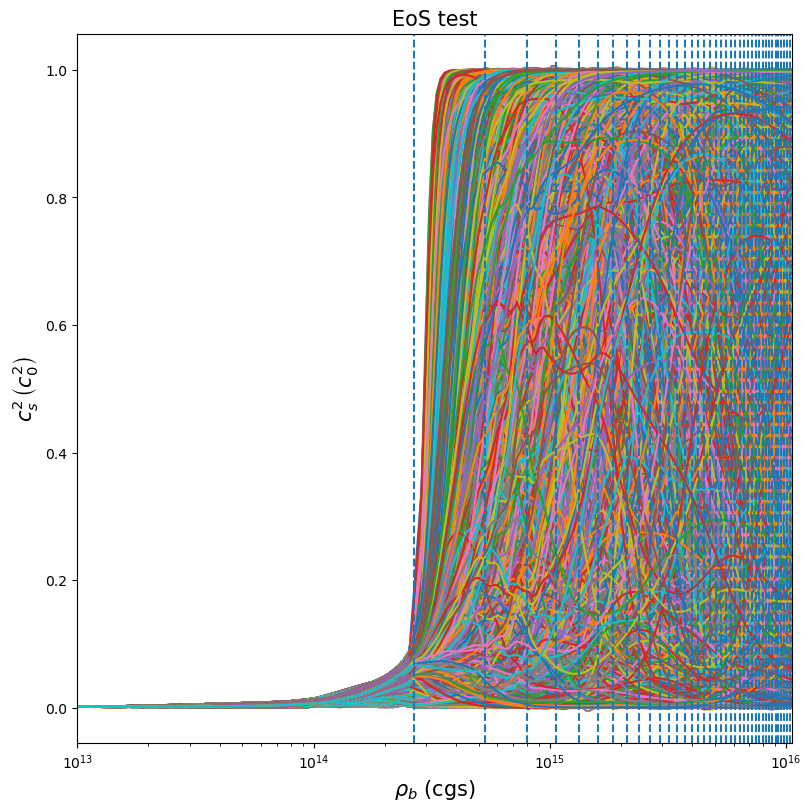

In [6]:
# Plotting c_s^2 of EoSs
plot_eos_samples(y_axis = "cs2",
                 title = r"EoS test",
                 xlabel = r"$\rho_b$ (cgs)",
                 ylabel = r"$c_s^2\,\left(c_0^2\right)$",
                 fig_name = "40rho_nuc_test1"
                )

## Filtering conformal EoSs

In [5]:
conformal_eos_sample, conformal_eos_sample_nums = filter_conformal_lenient(return_nums = True)

index of 10rho_0 is 460


100%|██████████| 150000/150000 [01:09<00:00, 2166.66it/s]


In [6]:
print(f"Number of conformal EoSs: {len(conformal_eos_sample)}")
print(f"Proportion of conformal EoSs: {len(conformal_eos_sample) / 150000}")

Number of conformal EoSs: 23516
Proportion of conformal EoSs: 0.15677333333333332


## Verifying that conformal h5 file was generated correctly

In [30]:
all_h5 = h5py.File("/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/gp_draws_ext_40.h5")
conformal_h5 = h5py.File("/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/conformal.h5")
print(all_h5.keys())
print(conformal_h5.keys())

<KeysViewHDF5 ['eos', 'id', 'mm_id', 'ns']>
<KeysViewHDF5 ['eos', 'id', 'mm_id']>


In [31]:
print(len(all_h5["eos"]))
print(len(conformal_h5["eos"]))

150000
23516


In [32]:
print(all_h5["eos"]["eos_002361"])
print(conformal_h5["eos"]["eos_002361"])

<HDF5 dataset "eos_002361": shape (498,), type "|V32">
<HDF5 dataset "eos_002361": shape (498,), type "|V32">


In [33]:
print(all_h5["eos"][f"eos_{2361:06d}"]["pressurec2"] - conformal_h5["eos"][f"eos_{2361:06d}"]["pressurec2"])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

## Manually pinching conformal EoSs

In [5]:
# One time only: get conformal_indices for updating pressure and energy density after cs2=1/3
# Also getting sample_nums to get conformal mass-radius contours (every time)
conformal_eos_sample, conformal_eos_sample_nums, conformal_indices = filter_conformal_lenient(return_indices = True, return_nums = True)

index of 10rho_0 is 460


100%|██████████| 150000/150000 [01:06<00:00, 2242.04it/s]


### Conformal h5 file

In [5]:
# Manually pinching EoSs (only need to do one time)
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
h5_path = f"{project_path}/conformal.h5"

def conformal_cs2(p, epsilon):
    return 1.0 / 3.0

with h5py.File(h5_path, "r+") as h5_file:
    eos_data = h5_file["eos"]

    for i in tqdm.tqdm(range(np.size(conformal_eos_sample))):
        conformal_index = conformal_indices[i]
    
        # Skipping if EoS becomes conformal at the very last index
        if conformal_index == 497:
            continue
            
        sample = eos_data[conformal_eos_sample[i]]
        pressure = sample["pressurec2"]
        energy_density = sample["energy_densityc2"]
    
        # Finding pre-conformal arrays (including conformal index)
        pre_conformal_pressure = pressure[:conformal_index + 1]
        pre_conformal_energy_density = energy_density[:conformal_index + 1]
    
        # Finding post-conformal arrays
        post_conformal_energy_density = energy_density[conformal_index:]
        
        # Pinching post-conformal arrays to cs2 = 1/3
        solution = integrate.solve_ivp(fun = conformal_cs2,
                                       t_span = [post_conformal_energy_density[0], post_conformal_energy_density[-1]],
                                       y0 = [pressure[conformal_index]],
                                       t_eval = post_conformal_energy_density
                                      )
    
        # Excluding conformal index
        new_post_conformal_pressure = solution.y[0][1:]
        new_post_conformal_energy_density = solution.t[1:]
    
        # Joining pre-conformal and post-conformal arrays
        new_pressure = np.concatenate((pre_conformal_pressure, new_post_conformal_pressure))
        new_energy_density = np.concatenate((pre_conformal_energy_density, new_post_conformal_energy_density))
    
        # Overwriting h5 data
        eos_data[conformal_eos_sample[i]]["pressurec2"] = new_pressure
        eos_data[conformal_eos_sample[i]]["energy_densityc2"] = new_energy_density

100%|██████████| 23516/23516 [00:46<00:00, 510.43it/s]


#### Verifying that pinching $c_s^2$ worked on conformal h5 file

In [11]:
with h5py.File(h5_path, "r+") as h5_file:
    eos_data = h5_file["eos"]
    cs2 = np.gradient(eos_data[conformal_eos_sample[0]]["pressurec2"], eos_data[conformal_eos_sample[0]]["energy_densityc2"])
    print(cs2)
    h5_file.close()

[3.67632150e-05 3.72392041e-05 3.82430239e-05 3.92764561e-05
 4.03238488e-05 4.14013060e-05 4.24933175e-05 4.36157945e-05
 4.47534537e-05 4.59219260e-05 4.71132036e-05 4.83223453e-05
 4.95634394e-05 5.08185869e-05 5.21081411e-05 5.34123575e-05
 5.47512920e-05 5.61055411e-05 5.74947657e-05 5.89000060e-05
 6.03404218e-05 6.18054143e-05 6.32908730e-05 6.48121146e-05
 6.63476135e-05 6.79224138e-05 6.95121913e-05 7.11414629e-05
 7.27864938e-05 7.44711595e-05 7.61724374e-05 7.79134406e-05
 7.96804967e-05 8.14711134e-05 8.33013678e-05 8.51459441e-05
 8.70351374e-05 8.89395709e-05 9.08887527e-05 9.28541768e-05
 9.48644390e-05 9.68920330e-05 9.89645140e-05 1.01064572e-04
 1.03192278e-04 1.05363885e-04 1.07550132e-04 1.09787183e-04
 1.12040074e-04 1.14343909e-04 1.16664882e-04 1.19036906e-04
 1.21427469e-04 1.23869157e-04 1.26340320e-04 1.28844702e-04
 1.31398034e-04 1.33966895e-04 1.36594054e-04 1.39238278e-04
 1.41941005e-04 1.44662441e-04 1.47442553e-04 1.50243131e-04
 1.53102523e-04 1.559938

### Prior h5 file

In [6]:
# Manually pinching EoSs (only need to do one time)
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
h5_path = f"{project_path}/prior_unpinched_ns.h5"

def conformal_cs2(p, epsilon):
    return 1.0 / 3.0

with h5py.File(h5_path, "r+") as h5_file:
    eos_data = h5_file["eos"]

    for i in tqdm.tqdm(range(np.size(conformal_eos_sample))):
        conformal_index = conformal_indices[i]
    
        # Skipping if EoS becomes conformal at the very last index
        if conformal_index == 497:
            continue
            
        sample = eos_data[conformal_eos_sample[i]]
        pressure = sample["pressurec2"]
        energy_density = sample["energy_densityc2"]
    
        # Finding pre-conformal arrays (including conformal index)
        pre_conformal_pressure = pressure[:conformal_index + 1]
        pre_conformal_energy_density = energy_density[:conformal_index + 1]
    
        # Finding post-conformal arrays
        post_conformal_energy_density = energy_density[conformal_index:]
        
        # Pinching post-conformal arrays to cs2 = 1/3
        solution = integrate.solve_ivp(fun = conformal_cs2,
                                       t_span = [post_conformal_energy_density[0], post_conformal_energy_density[-1]],
                                       y0 = [pressure[conformal_index]],
                                       t_eval = post_conformal_energy_density
                                      )
    
        # Excluding conformal index
        new_post_conformal_pressure = solution.y[0][1:]
        new_post_conformal_energy_density = solution.t[1:]
    
        # Joining pre-conformal and post-conformal arrays
        new_pressure = np.concatenate((pre_conformal_pressure, new_post_conformal_pressure))
        new_energy_density = np.concatenate((pre_conformal_energy_density, new_post_conformal_energy_density))
    
        # Overwriting h5 data
        eos_data[conformal_eos_sample[i]]["pressurec2"] = new_pressure
        eos_data[conformal_eos_sample[i]]["energy_densityc2"] = new_energy_density

100%|██████████| 23516/23516 [01:16<00:00, 306.53it/s]


#### Verifying that pinching $c_s^2$ worked on prior h5 file

In [7]:
with h5py.File(h5_path, "r+") as h5_file:
    eos_data = h5_file["eos"]
    cs2 = np.gradient(eos_data[conformal_eos_sample[0]]["pressurec2"], eos_data[conformal_eos_sample[0]]["energy_densityc2"])
    print(cs2)
    h5_file.close()

[3.67632150e-05 3.72392041e-05 3.82430239e-05 3.92764561e-05
 4.03238488e-05 4.14013060e-05 4.24933175e-05 4.36157945e-05
 4.47534537e-05 4.59219260e-05 4.71132036e-05 4.83223453e-05
 4.95634394e-05 5.08185869e-05 5.21081411e-05 5.34123575e-05
 5.47512920e-05 5.61055411e-05 5.74947657e-05 5.89000060e-05
 6.03404218e-05 6.18054143e-05 6.32908730e-05 6.48121146e-05
 6.63476135e-05 6.79224138e-05 6.95121913e-05 7.11414629e-05
 7.27864938e-05 7.44711595e-05 7.61724374e-05 7.79134406e-05
 7.96804967e-05 8.14711134e-05 8.33013678e-05 8.51459441e-05
 8.70351374e-05 8.89395709e-05 9.08887527e-05 9.28541768e-05
 9.48644390e-05 9.68920330e-05 9.89645140e-05 1.01064572e-04
 1.03192278e-04 1.05363885e-04 1.07550132e-04 1.09787183e-04
 1.12040074e-04 1.14343909e-04 1.16664882e-04 1.19036906e-04
 1.21427469e-04 1.23869157e-04 1.26340320e-04 1.28844702e-04
 1.31398034e-04 1.33966895e-04 1.36594054e-04 1.39238278e-04
 1.41941005e-04 1.44662441e-04 1.47442553e-04 1.50243131e-04
 1.53102523e-04 1.559938

## Contour plotting conformal vs prior

In [3]:
### Laying out plot densities and percentiles
plot_densities = np.geomspace(np.power(10.0, 13.0), 40.0 * rho_nuc_in_cgs, 500)
percentiles = [5, 95]

In [4]:
### Getting prior quantiles
prior_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/prior_pinched.h5"
prior_samples = meraki.EOS.load_samples(prior_h5_path, load_micro = True)
prior_pe_quantiles = prior_samples.get_pe_quantiles(plot_densities, percentiles)
prior_cs_quantiles = prior_samples.get_cs_quantiles(plot_densities, percentiles)

In [5]:
### Getting conformal quantiles
conformal_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/conformal.h5"
conformal_samples = meraki.EOS.load_samples(conformal_h5_path, load_micro = True)
conformal_pe_quantiles = conformal_samples.get_pe_quantiles(plot_densities, percentiles)
conformal_cs_quantiles = conformal_samples.get_cs_quantiles(plot_densities, percentiles)

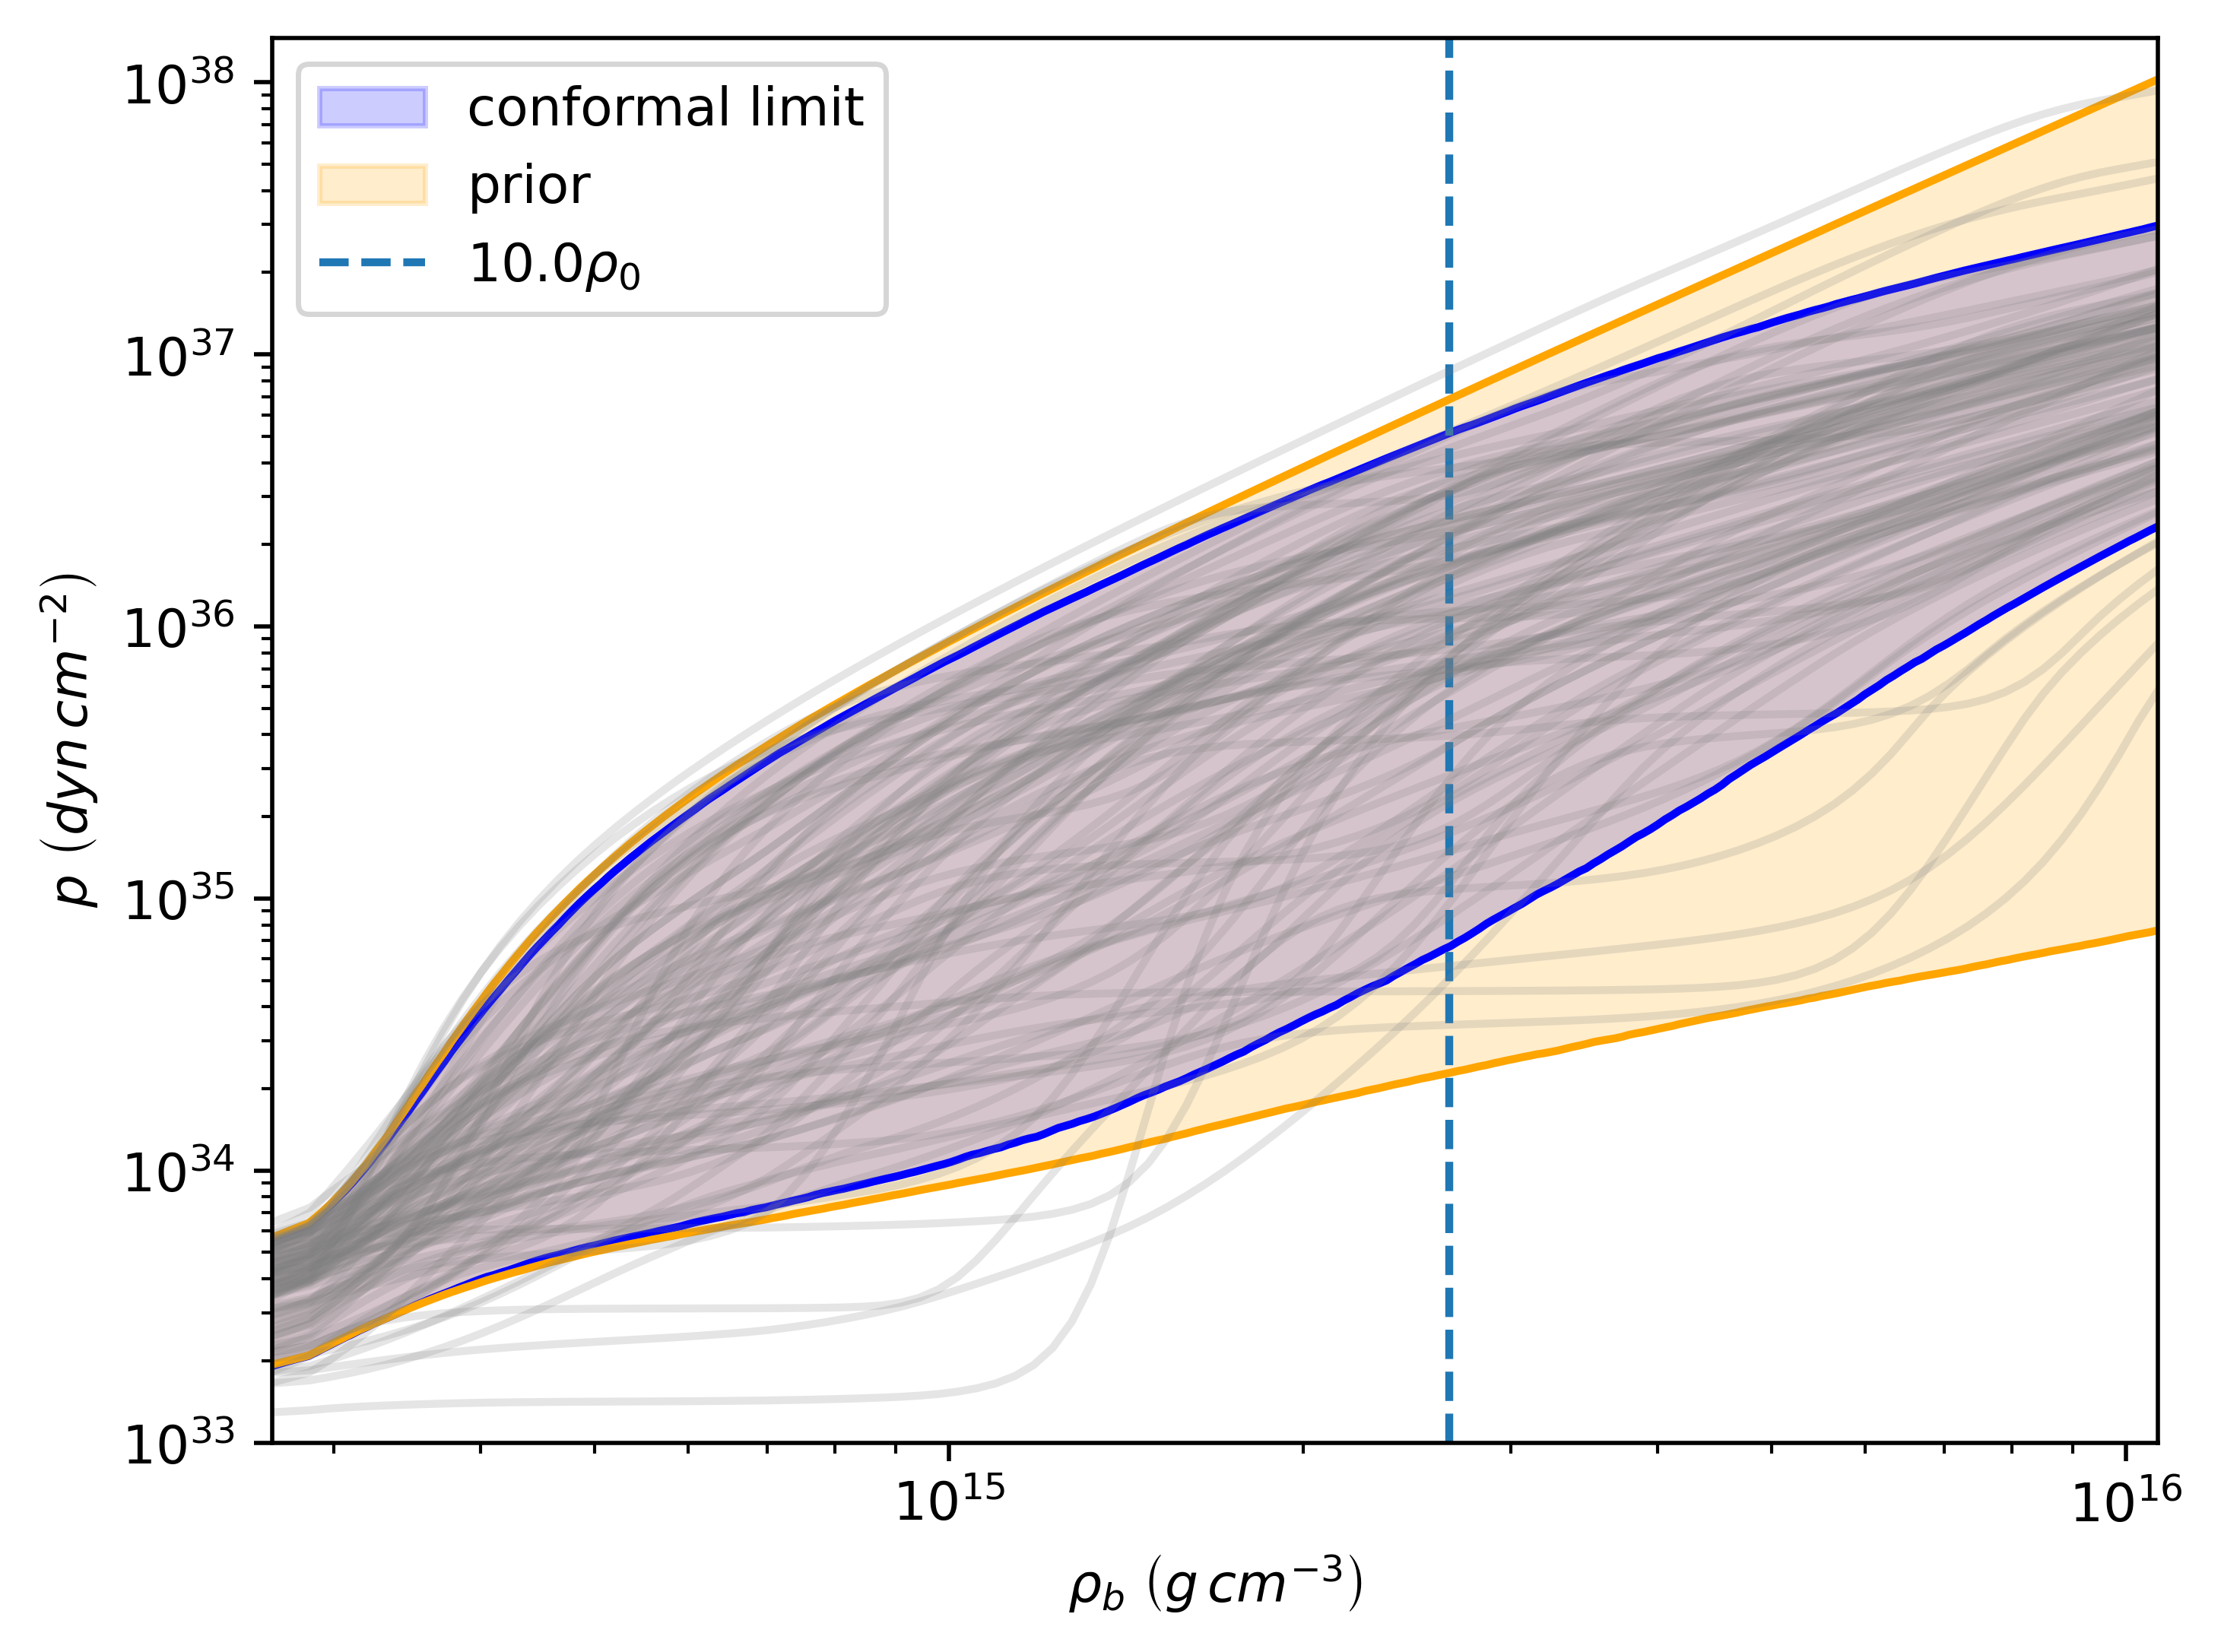

In [7]:
# Pressure contour
plt.loglog();
plt.xlabel(r"$\rho_b$ $\left(g\,cm^{-3}\right)$");
plt.ylabel(r"$p$ $\left(dyn\,cm^{-2}\right)$");
plt.xlim(1.0 * rho_nuc_in_cgs, 40.0 * rho_nuc_in_cgs);
plt.ylim(10.0 ** 33, 10.1 ** 38);

plt.fill_between(plot_densities,
                 conformal_pe_quantiles[:, 0],
                 conformal_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "blue",
                 label = "conformal limit"
                )

plt.fill_between(plot_densities,
                 prior_pe_quantiles[:, 0],
                 prior_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "orange",
                 label = "prior"
                )

plt.plot(plot_densities,
         conformal_pe_quantiles,
         color = "blue"
        );

plt.plot(plot_densities,
         prior_pe_quantiles,
         color = "orange"
        );

# Plotting rho_nuc markers
markers = [10.0]

for i in range(np.size(markers)):
    plt.axvline(x = markers[i] * rho_nuc_in_cgs, label = f"${markers[i]}$"r"$\rho_0$",
                linestyle = "--"
               );

# Plotting example draws of conformal EoS
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
conformal_h5_path = f"{project_path}/conformal.h5"
eos_indices = pd.read_csv(f"{project_path}/astro_likelihoods/conformal_weights_unpinched.csv")["eos_index"].to_numpy()

with h5py.File(conformal_h5_path) as h5_file:
    eos_data = h5_file["eos"]
    for i in range(100):
        sample = np.random.randint(0, len(eos_data))
        sample_key = f"eos_{eos_indices[sample]:06d}"
        
        plt.plot(eos_data[sample_key]["baryon_density"],
                 eos_data[sample_key]["pressurec2"] * gcm3_to_dynecm2,
                 color = "grey",
                 alpha = 0.2
                );

    h5_file.close()

plt.gcf().set_dpi(500)
plt.legend();

# Saving plot        
# plot_folder = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/plots"
# plt.savefig(f"{plot_folder}/pe_pinched_0.jpg", bbox_inches = "tight");
# plt.savefig(f"{plot_folder}/pe_pinched_0.pdf", bbox_inches = "tight");

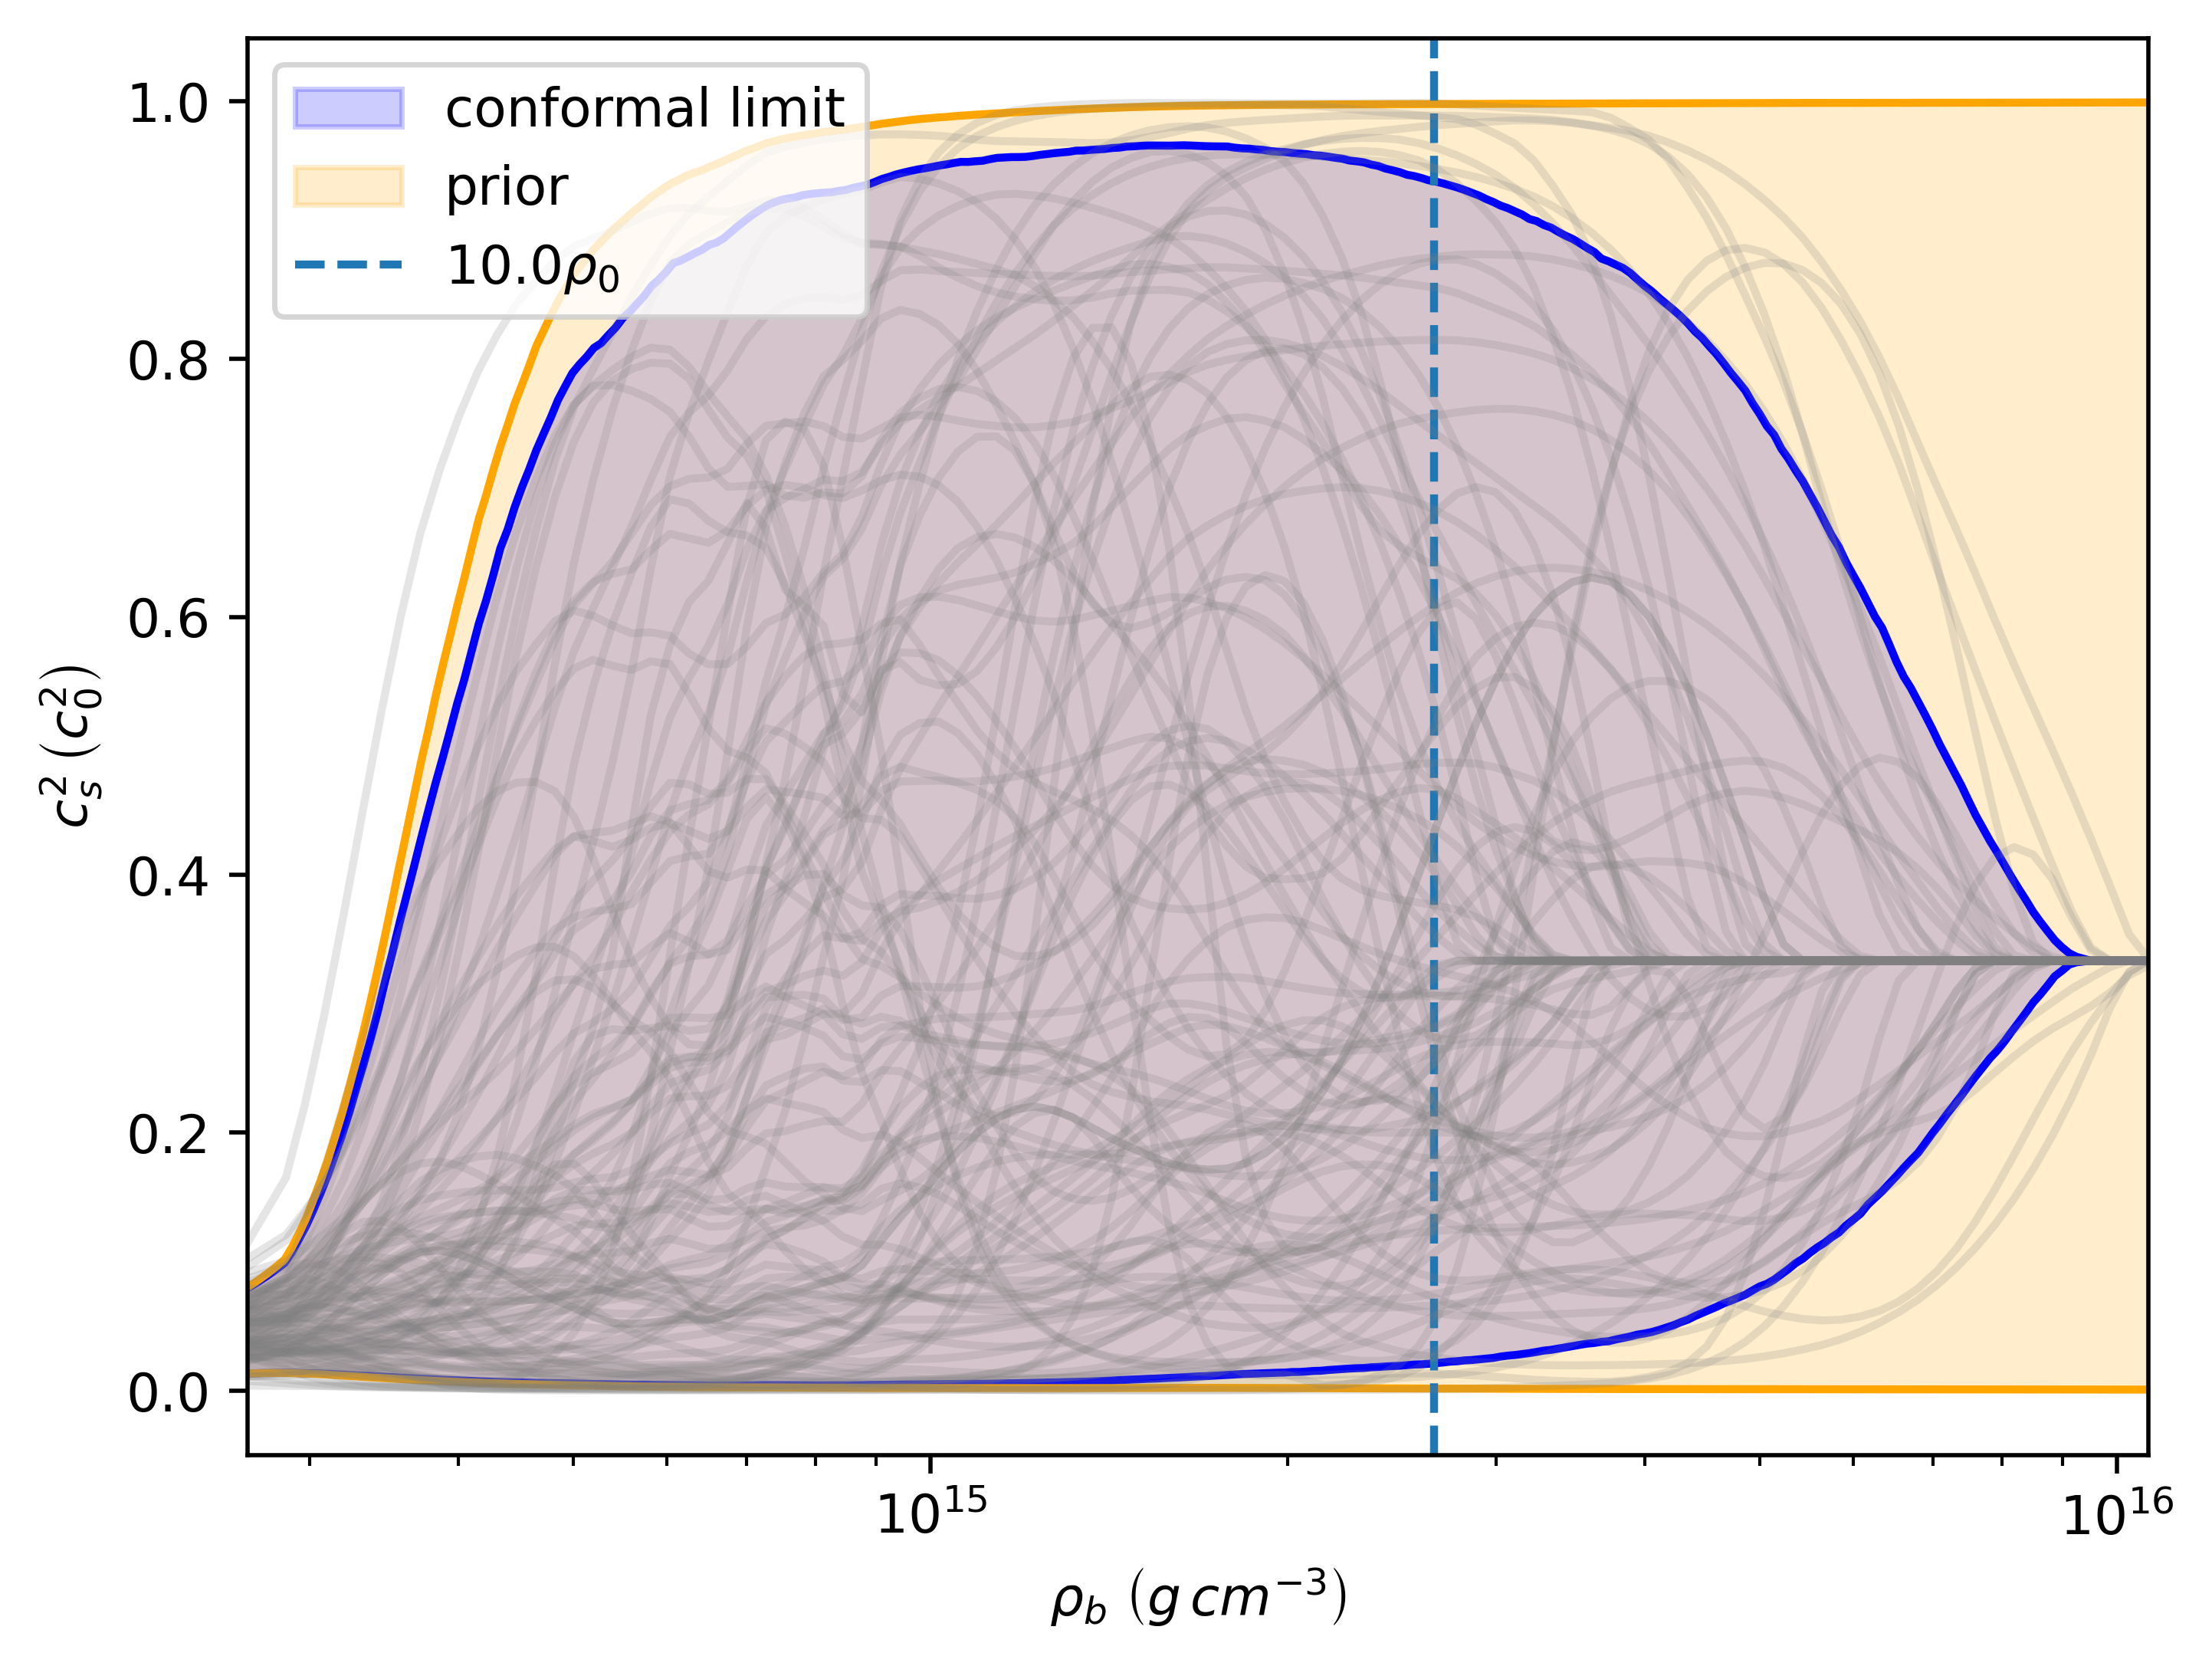

In [9]:
# Sound speed contour
plt.xscale("log");
plt.xlabel(r"$\rho_b$ $\left(g\,cm^{-3}\right)$");
plt.ylabel(r"$c_s^2\,\left(c_0^2\right)$");
plt.xlim(1.0 * rho_nuc_in_cgs, 40.0 * rho_nuc_in_cgs);


plt.fill_between(plot_densities,
                 conformal_cs_quantiles[:, 0],
                 conformal_cs_quantiles[:, 1],
                 alpha = 0.2,
                 color = "blue",
                 label = "conformal limit"
                )

plt.fill_between(plot_densities,
                 prior_cs_quantiles[:, 0],
                 prior_cs_quantiles[:, 1],
                 alpha = 0.2,
                 color = "orange",
                 label = "prior"
                )

plt.plot(plot_densities,
         conformal_cs_quantiles,
         color = "blue"
        );

plt.plot(plot_densities,
         prior_cs_quantiles,
         color = "orange"
        );

# Plotting rho_nuc markers
markers = [10.0]

for i in range(np.size(markers)):
    plt.axvline(x = markers[i] * rho_nuc_in_cgs, label = f"${markers[i]}$"r"$\rho_0$",
                linestyle = "--"
               );

# Plotting example draws of conformal EoS
with h5py.File(conformal_h5_path) as h5_file:
    eos_data = h5_file["eos"]
    for i in range(100):
        sample = np.random.randint(0, len(eos_data))
        sample_key = f"eos_{eos_indices[sample]:06d}"
        pressurec2 = eos_data[sample_key]["pressurec2"]
        energy_densityc2 = eos_data[sample_key]["energy_densityc2"]
        cs2 = np.gradient(pressurec2, energy_densityc2)
        plt.plot(eos_data[sample_key]["baryon_density"], cs2, color = "grey", alpha = 0.2);

    h5_file.close()

plt.gcf().set_dpi(500)
plt.legend();

# Saving plot        
# plot_folder = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/plots"
# plt.savefig(f"{plot_folder}/cs_pinched_0.jpg", bbox_inches = "tight");
# plt.savefig(f"{plot_folder}/cs_pinched_0.pdf", bbox_inches = "tight");

## Finding mass, radius, tidal deformability

### Overwriting prior h5 file w/ conformal EoS and NS data

In [7]:
# Manually overwriting prior h5 file w/ conformal EoS and NS data (only need to do one time)
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
prior_h5_path = f"{project_path}/prior_15rho_0_non_conformal.h5"
conformal_h5_path = f"{project_path}/conformal.h5"
conformal_eos_indices = pd.read_csv(f"{project_path}/astro_likelihoods/conformal_weights_unpinched.csv")["eos_index"].to_numpy()

with h5py.File(prior_h5_path, "r+") as prior_h5_file:
    prior_eos_data = prior_h5_file["eos"]
    prior_ns_data = prior_h5_file["ns"]

    with h5py.File(conformal_h5_path) as conformal_h5_file:
        conformal_eos_data = conformal_h5_file["eos"]
        conformal_ns_data = conformal_h5_file["ns"]
        
        for i in tqdm.tqdm(range(len(conformal_eos_data))):
            eos_sample_key = f"eos_{conformal_eos_indices[i]:06d}"
            ns_sample_key = f"eos_{i:06d}"    # Accounting for sequential indexing of conformal NS EoSs (incorrect due to TOV solver)
            eos = conformal_eos_data[eos_sample_key]
            ns = conformal_ns_data[ns_sample_key]

            # Reading data from conformal h5 file
            ### Only need to read pressure and energy density for EoS group, b/c all else is unchanged by pinching
            conformal_pressure = eos["pressurec2"]
            conformal_energy_density = eos["energy_densityc2"]

            ### NS data
            conformal_mass = ns["M"]
            conformal_radius = ns["R"]
            conformal_lambda = ns["Lambda"]
            conformal_rhoc = ns["rhoc"]
        
            # Overwriting prior h5 data
            ### Only need to transfer pressure and energy density for EoS group, b/c all else is unchanged by pinching
            prior_eos_data[eos_sample_key]["pressurec2"] = conformal_pressure
            prior_eos_data[eos_sample_key]["energy_densityc2"] = conformal_energy_density

            ### NS data (using the true EoS index, not incorrect one generated by TOV solver)
            ### Checking if there's a mismatch between the expected sizes
            n_alloc = prior_ns_data[eos_sample_key]["M"].shape[0]
            n_conf  = len(conformal_mass)
            
            if n_conf <= n_alloc:
                # Pad with NaN (or zeros) to fill the allocated space
                padded_M      = np.full(n_alloc, np.nan)
                padded_R      = np.full(n_alloc, np.nan)
                padded_Lambda = np.full(n_alloc, np.nan)
                padded_rhoc = np.full(n_alloc, np.nan)
                padded_M[:n_conf]      = conformal_mass
                padded_R[:n_conf]      = conformal_radius
                padded_Lambda[:n_conf] = conformal_lambda
                padded_rhoc[:n_conf] = conformal_rhoc
            else:
                # Truncate if somehow longer
                padded_M      = conformal_mass[:n_alloc]
                padded_R      = conformal_radius[:n_alloc]
                padded_Lambda = conformal_lambda[:n_alloc]
                padded_rhoc = conformal_rhoc[:n_alloc]
            
            prior_ns_data[eos_sample_key]["M"]      = padded_M
            prior_ns_data[eos_sample_key]["R"]      = padded_R
            prior_ns_data[eos_sample_key]["Lambda"] = padded_Lambda
            prior_ns_data[eos_sample_key]["rhoc"] = padded_rhoc
            
            # prior_ns_data[eos_sample_key]["M"] = conformal_mass
            # prior_ns_data[eos_sample_key]["R"] = conformal_radius
            # prior_ns_data[eos_sample_key]["Lambda"] = conformal_lambda
            # prior_ns_data[eos_sample_key]["rhoc"] = conformal_rhoc

        conformal_h5_file.close()

    prior_h5_file.close()

100%|██████████| 23516/23516 [02:18<00:00, 169.80it/s]


In [10]:
# Verifying that overwriting processed correctly
with h5py.File(prior_h5_path) as prior_h5_file:
    prior_eos_data = prior_h5_file["eos"]
    prior_ns_data = prior_h5_file["ns"]
    sample_key = f"eos_{conformal_eos_indices[0]:06d}"
    cs2 = np.gradient(prior_eos_data[sample_key]["pressurec2"], prior_eos_data[sample_key]["energy_densityc2"])
    print(f"cs2: {cs2}")

    with h5py.File(conformal_h5_path) as conformal_h5_file:
        conformal_eos_data = conformal_h5_file["eos"]
        conformal_ns_data = conformal_h5_file["ns"]
        pressure_diff = prior_eos_data[sample_key]["pressurec2"] - conformal_eos_data[sample_key]["pressurec2"]
        print(f"prior minus conformal pressure: {pressure_diff}")
        conformal_ns_sample_key = f"eos_{0:06d}"
        radius_diff = prior_ns_data[sample_key]["R"] - conformal_ns_data[conformal_ns_sample_key]["R"]
        print(f"prior minus conformal radius: {radius_diff}")
        conformal_h5_file.close()
        
    prior_h5_file.close()

cs2: [3.67632150e-05 3.72392041e-05 3.82430239e-05 3.92764561e-05
 4.03238488e-05 4.14013060e-05 4.24933175e-05 4.36157945e-05
 4.47534537e-05 4.59219260e-05 4.71132036e-05 4.83223453e-05
 4.95634394e-05 5.08185869e-05 5.21081411e-05 5.34123575e-05
 5.47512920e-05 5.61055411e-05 5.74947657e-05 5.89000060e-05
 6.03404218e-05 6.18054143e-05 6.32908730e-05 6.48121146e-05
 6.63476135e-05 6.79224138e-05 6.95121913e-05 7.11414629e-05
 7.27864938e-05 7.44711595e-05 7.61724374e-05 7.79134406e-05
 7.96804967e-05 8.14711134e-05 8.33013678e-05 8.51459441e-05
 8.70351374e-05 8.89395709e-05 9.08887527e-05 9.28541768e-05
 9.48644390e-05 9.68920330e-05 9.89645140e-05 1.01064572e-04
 1.03192278e-04 1.05363885e-04 1.07550132e-04 1.09787183e-04
 1.12040074e-04 1.14343909e-04 1.16664882e-04 1.19036906e-04
 1.21427469e-04 1.23869157e-04 1.26340320e-04 1.28844702e-04
 1.31398034e-04 1.33966895e-04 1.36594054e-04 1.39238278e-04
 1.41941005e-04 1.44662441e-04 1.47442553e-04 1.50243131e-04
 1.53102523e-04 1.5

### Correcting EoS indices of conformal h5 NS group

In [24]:
# Manually renaming EoS indices in conformal h5 NS group (only need to do one time)
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
h5_path = f"{project_path}/conformal.h5"
conformal_eos_indices = pd.read_csv(f"{project_path}/astro_likelihoods/conformal_weights_unpinched.csv")["eos_index"].to_numpy()

with h5py.File(h5_path, "r+") as h5_file:
    ns_data = h5_file["ns"]

    # First renaming to placeholder key to avoid overwriting or deleting
    for i in tqdm.tqdm(range(len(conformal_eos_indices))):
        old_sample_key = f"eos_{i:06d}"
        intermediate_sample_key = f"placeholder_{i:06d}"
        ns_data.move(old_sample_key, intermediate_sample_key)

    # Renaming to correct index
    for j in tqdm.tqdm(range(len(conformal_eos_indices))):
        intermediate_sample_key = f"placeholder_{j:06d}"
        new_sample_key = f"eos_{conformal_eos_indices[j]:06d}"
        ns_data.move(intermediate_sample_key, new_sample_key)

    h5_file.close()

100%|██████████| 23516/23516 [00:00<00:00, 52441.51it/s]


In [26]:
# Verifying that renaming processed correctly
with h5py.File(h5_path) as h5_file:
    ns_data = h5_file["ns"]
    print(ns_data.keys())
    print(len(ns_data))
    h5_file.close()

<KeysViewHDF5 ['eos_000008', 'eos_000011', 'eos_000012', 'eos_000013', 'eos_000022', 'eos_000027', 'eos_000035', 'eos_000042', 'eos_000047', 'eos_000048', 'eos_000049', 'eos_000051', 'eos_000053', 'eos_000057', 'eos_000068', 'eos_000069', 'eos_000072', 'eos_000075', 'eos_000081', 'eos_000084', 'eos_000088', 'eos_000095', 'eos_000096', 'eos_000097', 'eos_000107', 'eos_000110', 'eos_000111', 'eos_000123', 'eos_000142', 'eos_000144', 'eos_000154', 'eos_000158', 'eos_000163', 'eos_000164', 'eos_000170', 'eos_000174', 'eos_000178', 'eos_000194', 'eos_000197', 'eos_000211', 'eos_000218', 'eos_000220', 'eos_000229', 'eos_000230', 'eos_000235', 'eos_000240', 'eos_000241', 'eos_000252', 'eos_000254', 'eos_000260', 'eos_000262', 'eos_000271', 'eos_000273', 'eos_000282', 'eos_000288', 'eos_000289', 'eos_000301', 'eos_000306', 'eos_000309', 'eos_000313', 'eos_000314', 'eos_000324', 'eos_000334', 'eos_000337', 'eos_000340', 'eos_000342', 'eos_000343', 'eos_000345', 'eos_000347', 'eos_000351', 'eos_

### Plotting mass-radius

In [11]:
### Setting plot masses and percentiles
plot_masses = np.linspace(0.5, 4.0, 500)
percentiles = [5, 95]

In [12]:
### Getting prior quantiles
prior_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/prior_15rho_0_non_conformal.h5"
prior_samples = meraki.EOS.load_samples(prior_h5_path, load_macro = True)
prior_mr_quantiles = prior_samples.get_mr_quantiles(plot_masses, percentiles)

/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [13]:
### Getting conformal quantiles
conformal_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/conformal.h5"
conformal_samples = meraki.EOS.load_samples(conformal_h5_path, load_macro = True)
conformal_mr_quantiles = conformal_samples.get_mr_quantiles(plot_masses, percentiles)

In [10]:
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
conformal_h5_path = f"{project_path}/conformal.h5"
with h5py.File(conformal_h5_path) as h5_file:
    ns_data = h5_file["ns"]
    print(ns_data.keys())
    h5_file.close()

<KeysViewHDF5 ['eos_000000', 'eos_000001', 'eos_000002', 'eos_000003', 'eos_000004', 'eos_000005', 'eos_000006', 'eos_000007', 'eos_000008', 'eos_000009', 'eos_000010', 'eos_000011', 'eos_000012', 'eos_000013', 'eos_000014', 'eos_000015', 'eos_000016', 'eos_000017', 'eos_000018', 'eos_000019', 'eos_000020', 'eos_000021', 'eos_000022', 'eos_000023', 'eos_000024', 'eos_000025', 'eos_000026', 'eos_000027', 'eos_000028', 'eos_000029', 'eos_000030', 'eos_000031', 'eos_000032', 'eos_000033', 'eos_000034', 'eos_000035', 'eos_000036', 'eos_000037', 'eos_000038', 'eos_000039', 'eos_000040', 'eos_000041', 'eos_000042', 'eos_000043', 'eos_000044', 'eos_000045', 'eos_000046', 'eos_000047', 'eos_000048', 'eos_000049', 'eos_000050', 'eos_000051', 'eos_000052', 'eos_000053', 'eos_000054', 'eos_000055', 'eos_000056', 'eos_000057', 'eos_000058', 'eos_000059', 'eos_000060', 'eos_000061', 'eos_000062', 'eos_000063', 'eos_000064', 'eos_000065', 'eos_000066', 'eos_000067', 'eos_000068', 'eos_000069', 'eos_

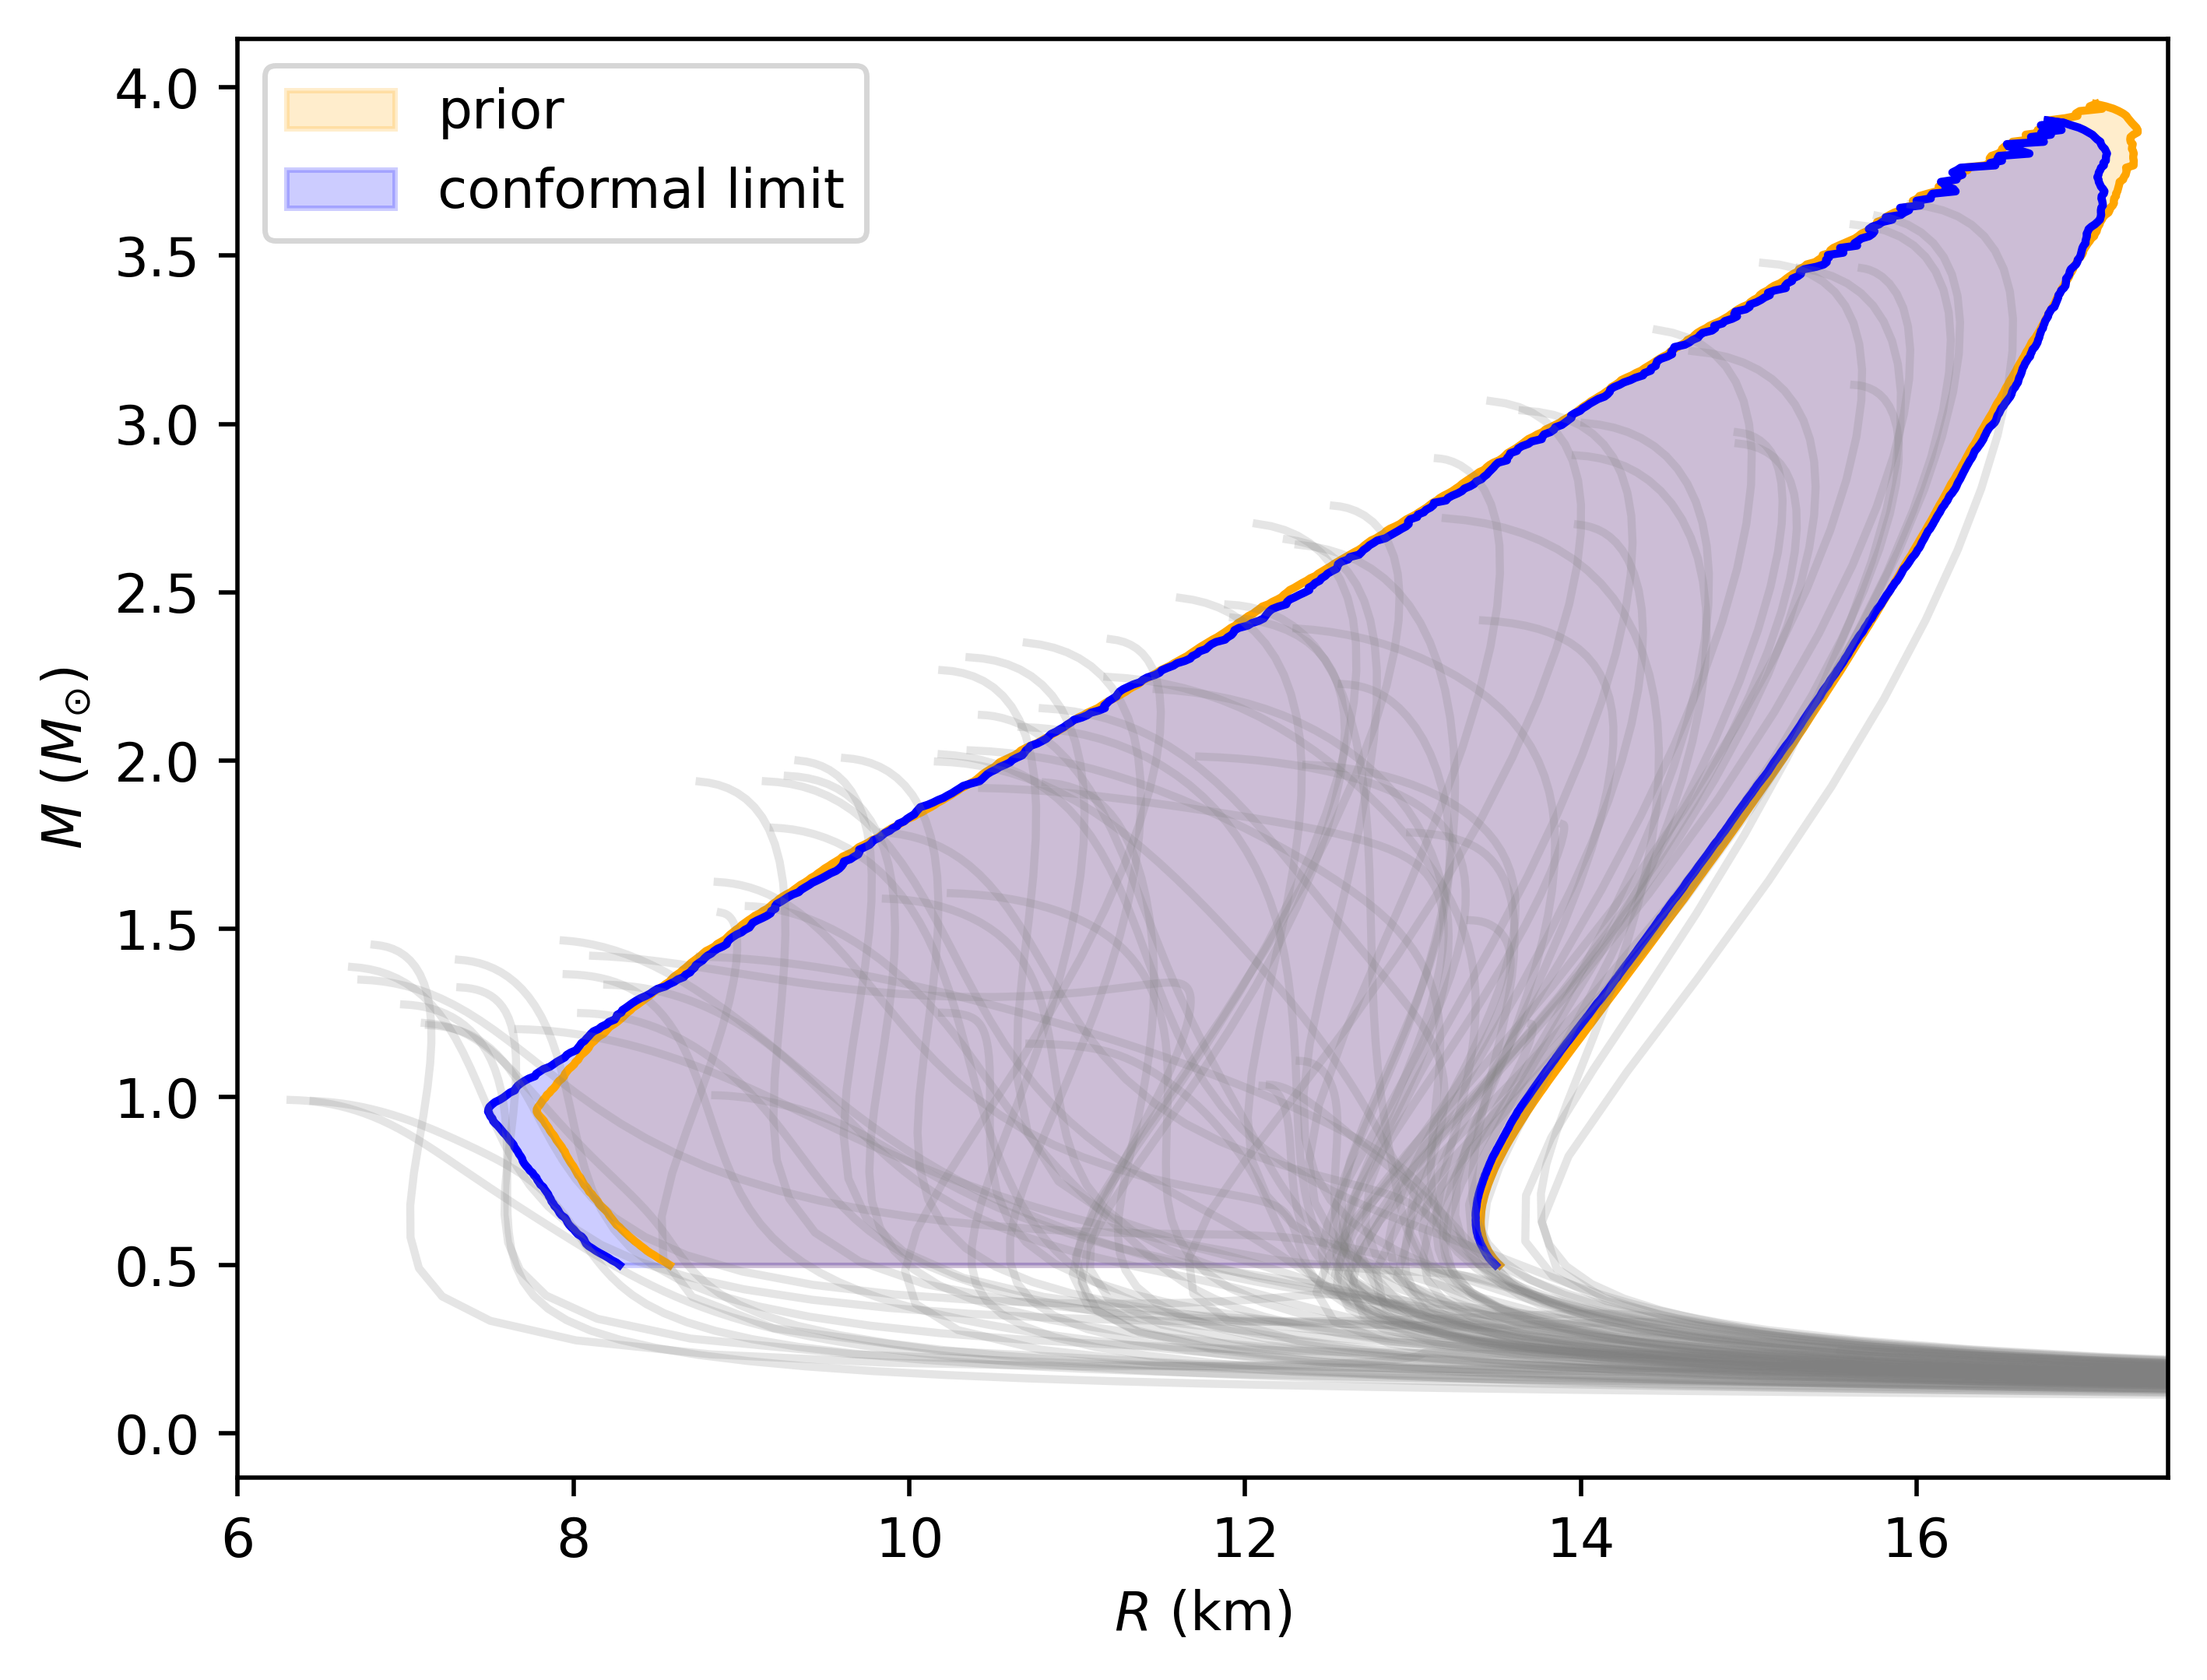

In [15]:
# Mass-radius contour
plt.xlabel(r"$R$ $\left(\mathrm{km}\right)$");
plt.ylabel(r"$M$ $\left(M_{\odot}\right)$");
plt.xlim(6, 17.5);

plt.fill_betweenx(plot_masses,
                  prior_mr_quantiles[:, 0],
                  prior_mr_quantiles[:, 1],
                  alpha = 0.2,
                  color = "orange",
                  label = "prior"
                 )

plt.fill_betweenx(plot_masses,
                  conformal_mr_quantiles[:, 0],
                  conformal_mr_quantiles[:, 1],
                  alpha = 0.2,
                  color = "blue",
                  label = "conformal limit"
                 )

plt.plot(prior_mr_quantiles,
         plot_masses,
         color = "orange"
        );

plt.plot(conformal_mr_quantiles,
         plot_masses,
         color = "blue"
        );

plt.gcf().set_dpi(500)
plt.legend();

# Plotting example draws of conformal EoS
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
conformal_h5_path = f"{project_path}/conformal.h5"
with h5py.File(conformal_h5_path) as h5_file:
    ns_data = h5_file["ns"]

    for i in range(100):
        sample = np.random.randint(0, len(ns_data))
        mass = ns_data[f"eos_{sample:06d}"]["M"]
        radius = ns_data[f"eos_{sample:06d}"]["R"]
        plt.plot(radius, mass, color = "grey", alpha = 0.2);

    h5_file.close()

# Saving plot        
# plot_folder = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/plots"
# plt.savefig(f"{plot_folder}/mr_pinched_0.jpg", bbox_inches = "tight");
# plt.savefig(f"{plot_folder}/mr_pinched_0.pdf", bbox_inches = "tight");

## Pulsar inference

### Generating pulsar weights using astro_pipe.py, and weighting EoSs

In [30]:
# Getting weighted prior
weights_file = pd.read_csv("/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/astro_likelihoods/pulsar_weights.csv")

weighted_eoss = meraki.get_and_load_weights(weights = weights_file,
                                            astro_tag = "joint_logweight",
                                            eos_set_to_use = np.arange(150000),
                                            Neff = True
                                           )

Number of effective EoS's: 51560
[92258 63974 68355 ...  1459 64667 47083]


In [17]:
# Filtering weights to only include conformal EoSs
weights_conformal_df = weights_file.copy()
weights_conformal_df = weights_conformal_df[weights_conformal_df["eos_index"].isin(conformal_eos_indices)]

weights_conformal_df.to_csv("/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/astro_likelihoods/conformal_weights.csv",
                            index = False
                           )

In [32]:
# Getting weighted posterior (conformal)
conformal_eos_indices = pd.read_csv(f"{project_path}/astro_likelihoods/conformal_weights_unpinched.csv")["eos_index"].to_numpy()

weighted_conformal_eoss = meraki.get_and_load_weights(weights = weights_conformal_df,
                                                      astro_tag = "joint_logweight",
                                                      eos_set_to_use = np.arange(len(conformal_eos_indices)),
                                                      Neff = True
                                                     )

Number of effective EoS's: 7452


### Plotting PSR weighted EoSs

In [20]:
### Setting plot densities, masses, and percentiles
plot_densities = np.geomspace(np.power(10.0, 13.0), 40.0 * rho_nuc_in_cgs, 500)
plot_masses = np.linspace(0.5, 4.0, 500)
percentiles = [5, 95]

In [36]:
### Setting prior and conformal h5 paths
prior_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/prior_15rho_0_non_conformal.h5"
conformal_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/conformal.h5"

In [37]:
### Getting prior quantiles
prior_samples = meraki.EOS.load_samples(prior_h5_path, load_micro = True, load_macro = True)
prior_pe_quantiles = prior_samples.get_pe_quantiles(plot_densities, percentiles)
prior_cs_quantiles = prior_samples.get_cs_quantiles(plot_densities, percentiles)
prior_mr_quantiles = prior_samples.get_mr_quantiles(plot_masses, percentiles)

/cvmfs/software.igwn.org/conda/envs/igwn/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [38]:
### Getting prior + PSR quantiles
prior_psr_samples = meraki.EOS.load_samples(prior_h5_path, load_micro = True, load_macro = True, downsample = True, specific_rng = weighted_eoss)
prior_psr_pe_quantiles = prior_psr_samples.get_pe_quantiles(plot_densities, percentiles)
prior_psr_cs_quantiles = prior_psr_samples.get_cs_quantiles(plot_densities, percentiles)
prior_psr_mr_quantiles = prior_psr_samples.get_mr_quantiles(plot_masses, percentiles)

In [39]:
### Getting pQCD quantiles
conformal_samples = meraki.EOS.load_samples(conformal_h5_path,
                                            load_micro = True,
                                            load_macro = True
                                           )

conformal_pe_quantiles = conformal_samples.get_pe_quantiles(plot_densities, percentiles)
conformal_cs_quantiles = conformal_samples.get_cs_quantiles(plot_densities, percentiles)
conformal_mr_quantiles = conformal_samples.get_mr_quantiles(plot_masses, percentiles)

In [40]:
### Getting pQCD + PSR quantiles
conformal_psr_samples = meraki.EOS.load_samples(conformal_h5_path,
                                                load_micro = True,
                                                load_macro = True,
                                                downsample = True,
                                                specific_rng = weighted_conformal_eoss
                                               )

conformal_psr_pe_quantiles = conformal_psr_samples.get_pe_quantiles(plot_densities, percentiles)
conformal_psr_cs_quantiles = conformal_psr_samples.get_cs_quantiles(plot_densities, percentiles)
conformal_psr_mr_quantiles = conformal_psr_samples.get_mr_quantiles(plot_masses, percentiles)

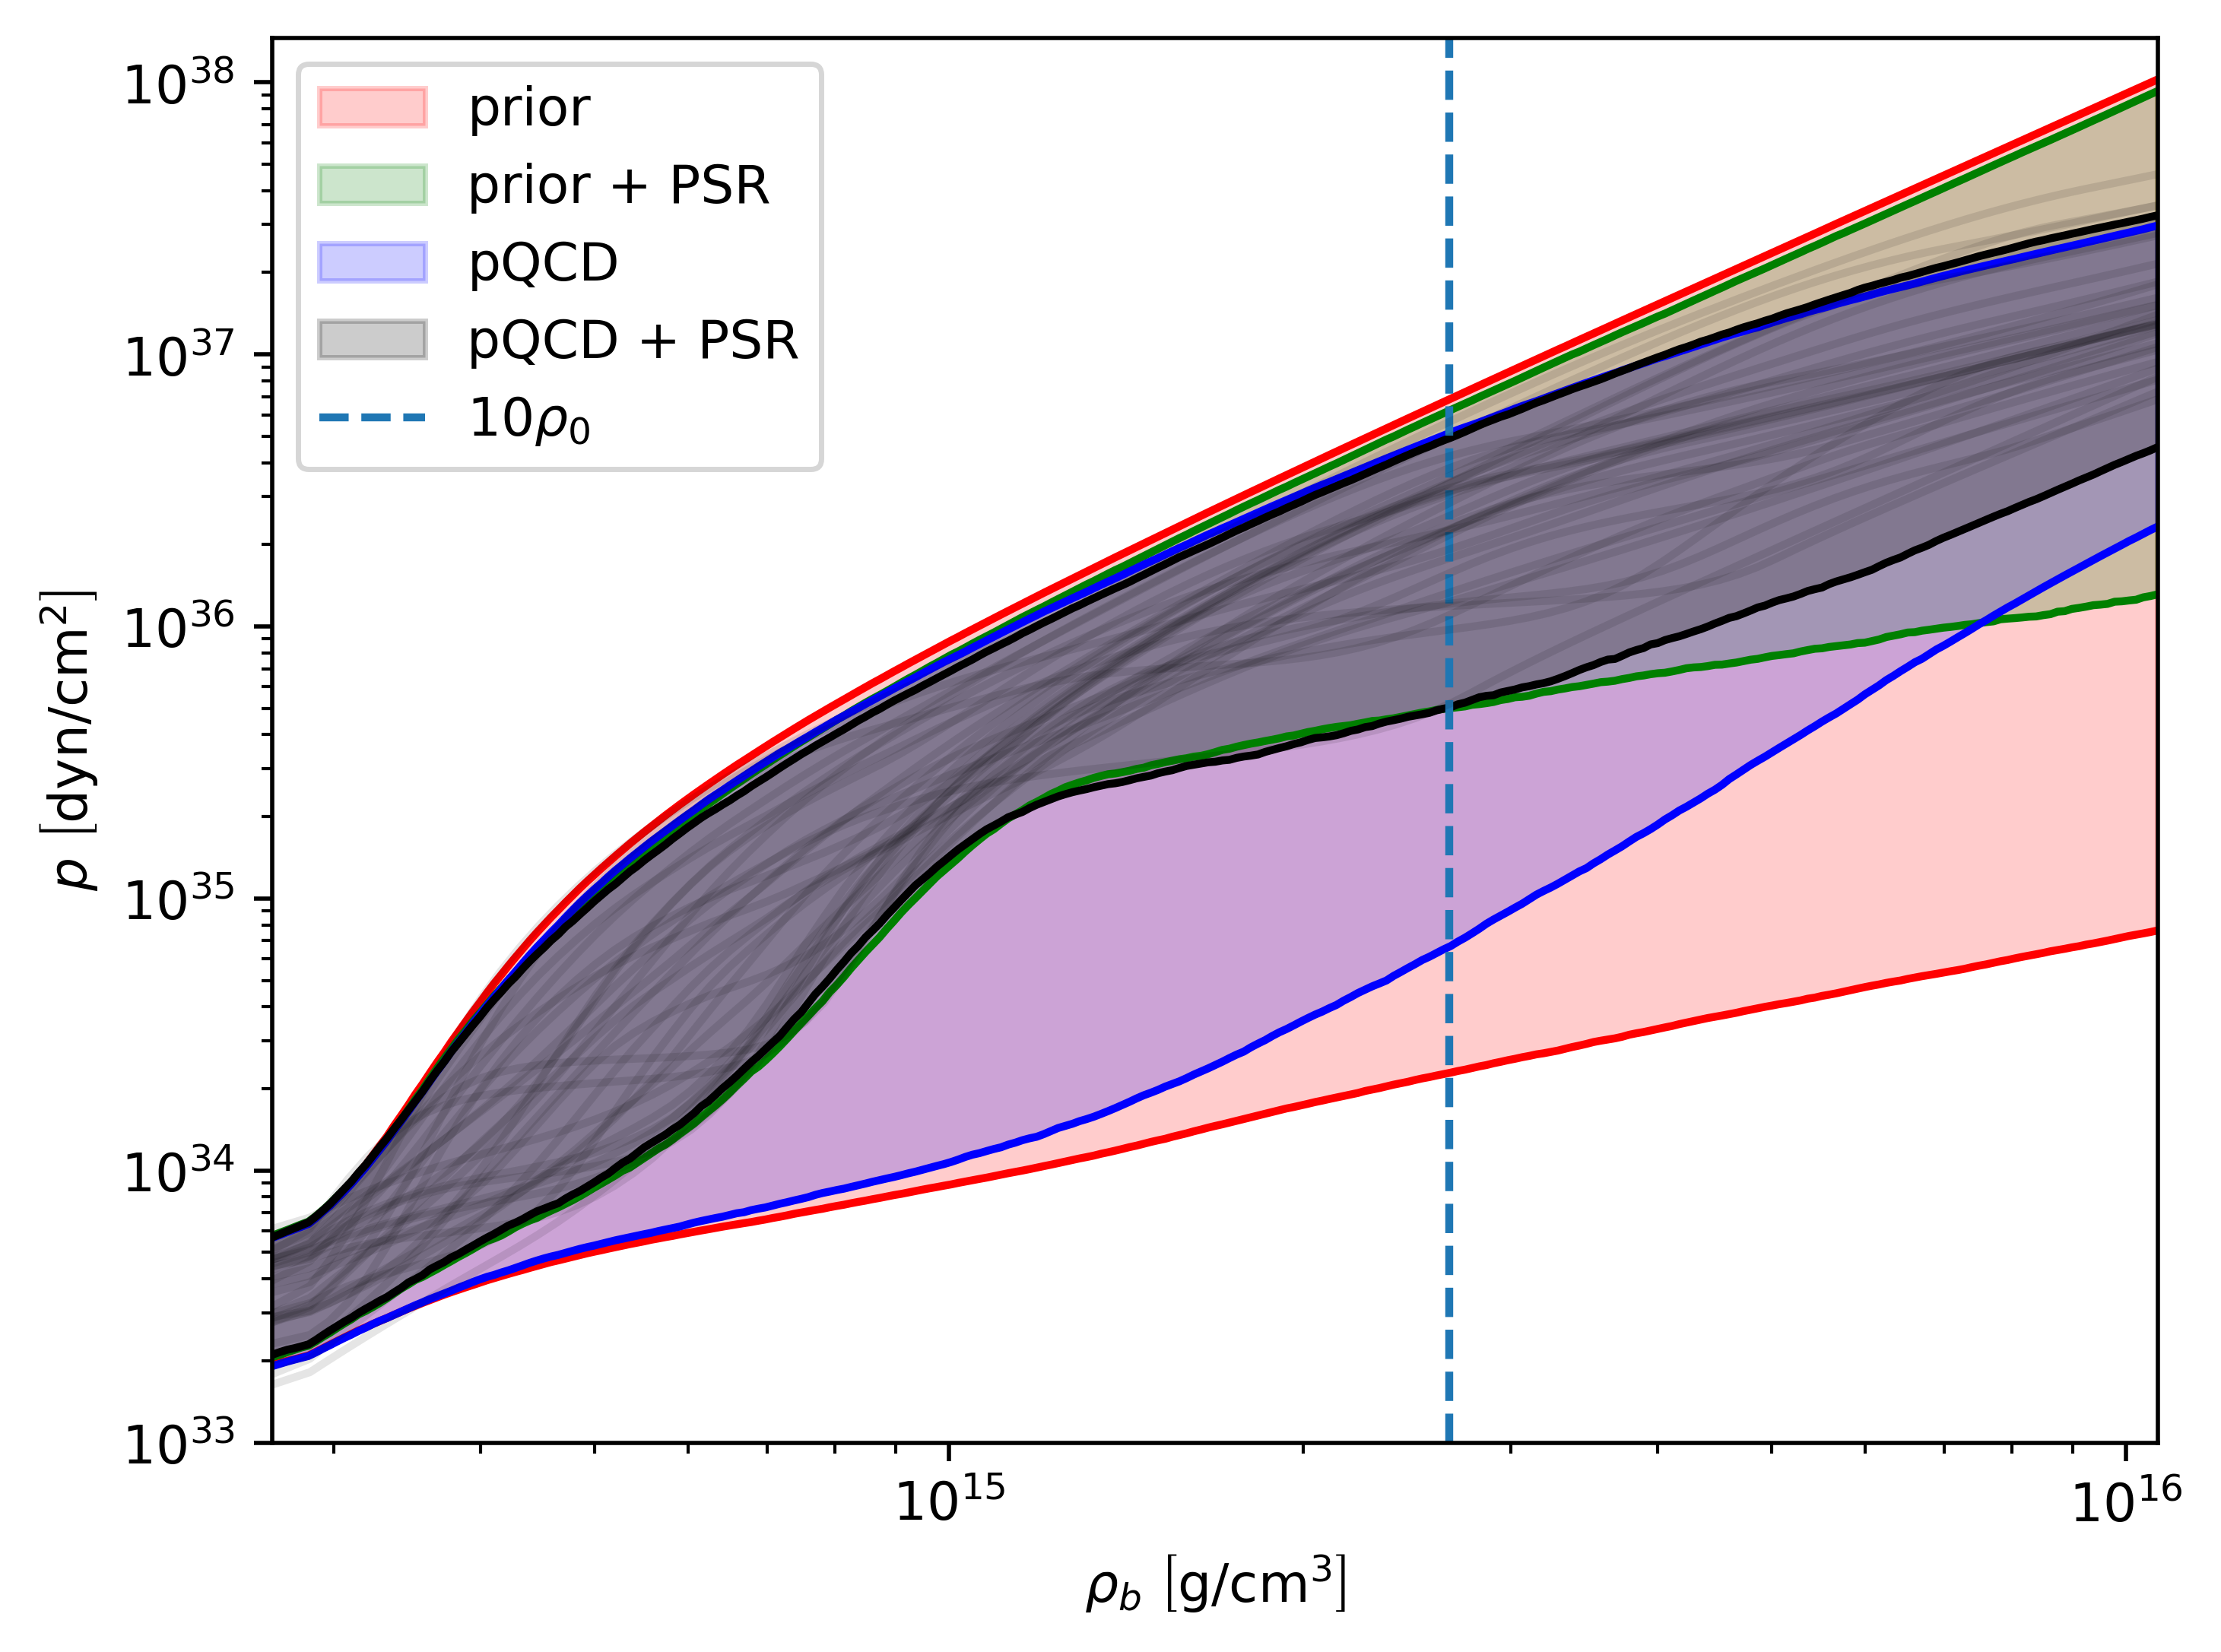

In [75]:
# Pressure contour
plt.loglog();
plt.xlabel(r"$\rho_b$ $\left[\mathrm{g/cm^{3}}\right]$");
plt.ylabel(r"$p$ $\left[\mathrm{dyn/cm^{2}}\right]$");
plt.xlim(1.0 * rho_nuc_in_cgs, 40.0 * rho_nuc_in_cgs);
plt.ylim(10.0 ** 33, 10.1 ** 38);

plt.fill_between(plot_densities,
                 prior_pe_quantiles[:, 0],
                 prior_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "red",
                 label = "prior"
                )

plt.fill_between(plot_densities,
                 prior_psr_pe_quantiles[:, 0],
                 prior_psr_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "green",
                 label = "prior + PSR"
                )

plt.fill_between(plot_densities,
                 conformal_pe_quantiles[:, 0],
                 conformal_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "blue",
                 label = "pQCD"
                )

plt.fill_between(plot_densities,
                 conformal_psr_pe_quantiles[:, 0],
                 conformal_psr_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "black",
                 label = "pQCD + PSR"
                )

plt.plot(plot_densities,
         prior_pe_quantiles,
         color = "red"
        );

plt.plot(plot_densities,
         prior_psr_pe_quantiles,
         color = "green"
        );

plt.plot(plot_densities,
         conformal_pe_quantiles,
         color = "blue"
        );

plt.plot(plot_densities,
         conformal_psr_pe_quantiles,
         color = "black"
        );

# Plotting rho_nuc markers
plt.axvline(x = 10.0 * rho_nuc_in_cgs, label = f"${10}$"r"$\rho_0$",
            linestyle = "--"
           );

# Plotting example draws of conformal EoS
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
h5_path = f"{project_path}/conformal.h5"
conformal_eos_indices = pd.read_csv(f"{project_path}/astro_likelihoods/conformal_weights_unpinched.csv")["eos_index"].to_numpy()

with h5py.File(h5_path) as h5_file:
    eos_data = h5_file["eos"]
    for i in range(30):
        sample = np.random.randint(0, len(weighted_conformal_eoss))
        weight_index = weighted_conformal_eoss[sample]
        sample_key = f"eos_{conformal_eos_indices[weight_index]:06d}"
        
        plt.plot(eos_data[sample_key]["baryon_density"],
                 eos_data[sample_key]["pressurec2"] * gcm3_to_dynecm2,
                 color = "black",
                 alpha = 0.1
                );

    h5_file.close()

plt.gcf().set_dpi(500)
plt.legend();

# Saving plot        
plot_folder = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/plots"
plt.savefig(f"{plot_folder}/pe_PSR_0.jpg", bbox_inches = "tight");
plt.savefig(f"{plot_folder}/pe_PSR_0.pdf", bbox_inches = "tight");

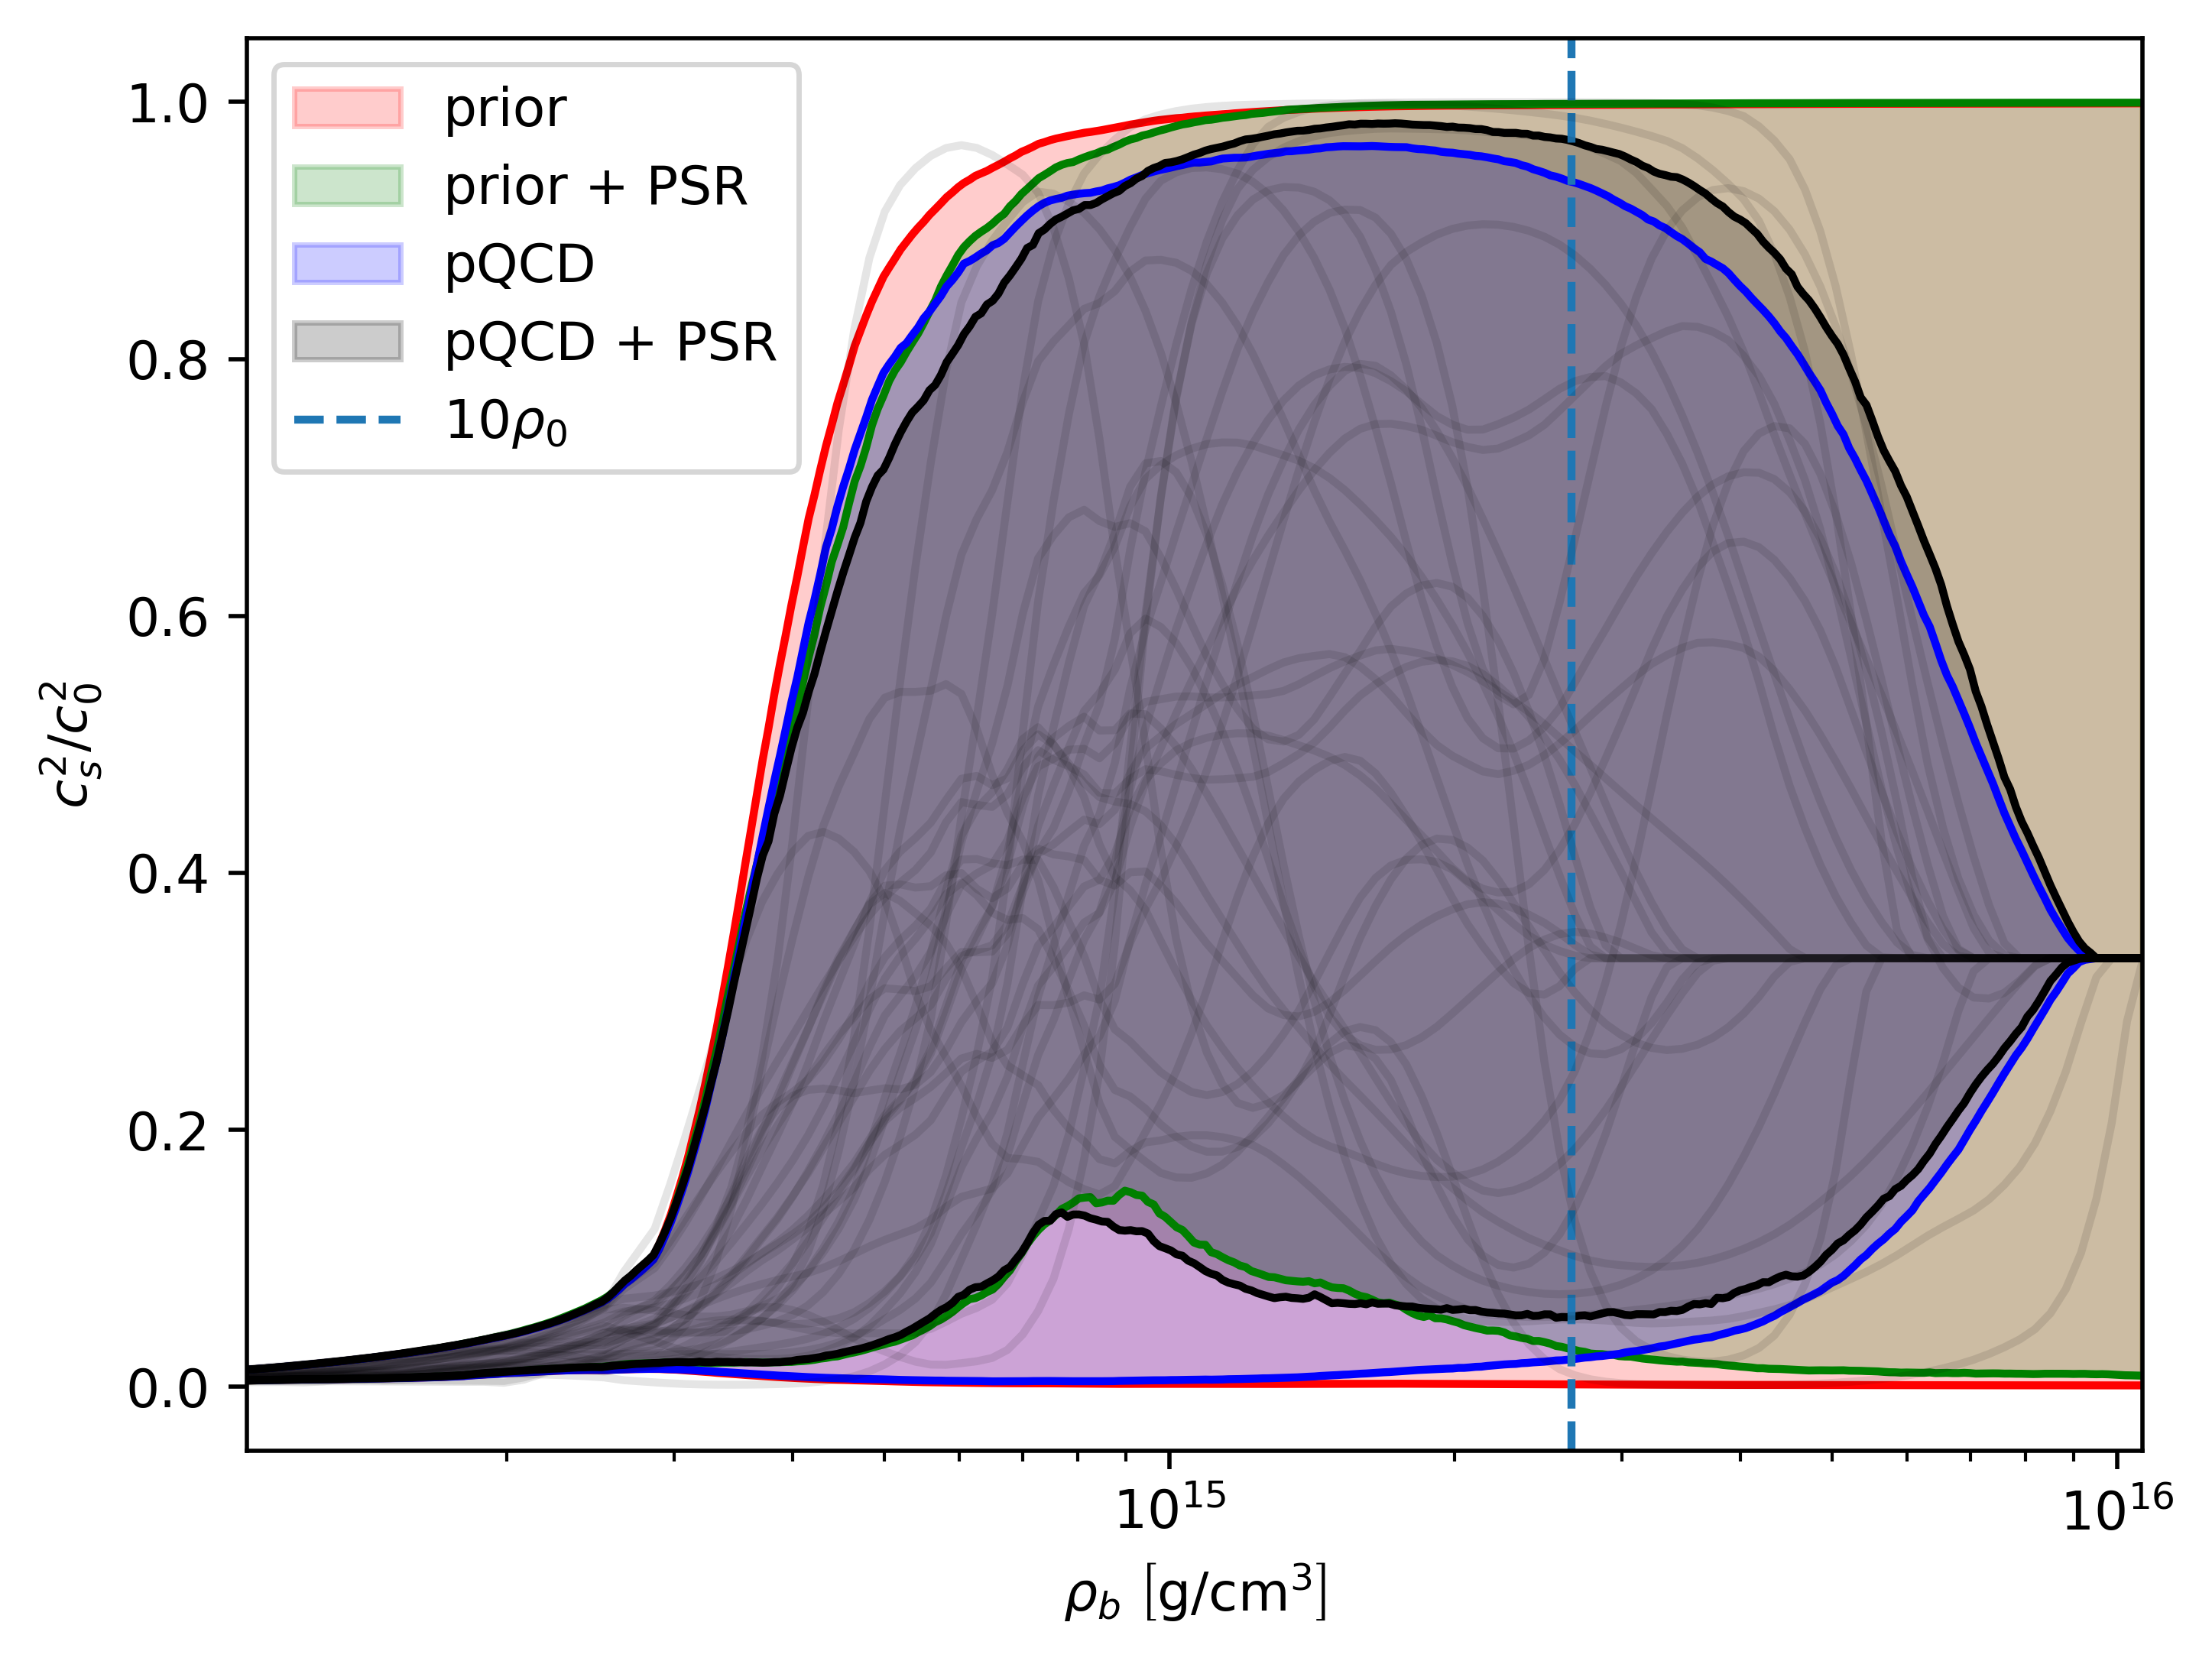

In [78]:
# Sound speed contour
plt.xscale("log");
plt.xlabel(r"$\rho_b$ $\left[\mathrm{g/cm^{3}}\right]$");
plt.ylabel(r"$c_s^2/c_0^2$");
plt.xlim(0.4 * rho_nuc_in_cgs, 40.0 * rho_nuc_in_cgs);

plt.fill_between(plot_densities,
                 prior_cs_quantiles[:, 0],
                 prior_cs_quantiles[:, 1],
                 alpha = 0.2,
                 color = "red",
                 label = "prior"
                )

plt.fill_between(plot_densities,
                 prior_psr_cs_quantiles[:, 0],
                 prior_psr_cs_quantiles[:, 1],
                 alpha = 0.2,
                 color = "green",
                 label = "prior + PSR"
                )

plt.fill_between(plot_densities,
                 conformal_cs_quantiles[:, 0],
                 conformal_cs_quantiles[:, 1],
                 alpha = 0.2,
                 color = "blue",
                 label = "pQCD"
                )

plt.fill_between(plot_densities,
                 conformal_psr_cs_quantiles[:, 0],
                 conformal_psr_cs_quantiles[:, 1],
                 alpha = 0.2,
                 color = "black",
                 label = "pQCD + PSR"
                )

plt.plot(plot_densities,
         prior_cs_quantiles,
         color = "red"
        );

plt.plot(plot_densities,
         prior_psr_cs_quantiles,
         color = "green"
        );

plt.plot(plot_densities,
         conformal_cs_quantiles,
         color = "blue"
        );

plt.plot(plot_densities,
         conformal_psr_cs_quantiles,
         color = "black"
        );

# Plotting rho_nuc markers
plt.axvline(x = 10.0 * rho_nuc_in_cgs, label = f"${10}$"r"$\rho_0$",
            linestyle = "--"
           );

# Plotting example draws of conformal EoS
with h5py.File(conformal_h5_path) as h5_file:
    eos_data = h5_file["eos"]
    for i in range(30):
        sample = np.random.randint(0, len(weighted_conformal_eoss))
        weight_index = weighted_conformal_eoss[sample]
        sample_key = f"eos_{conformal_eos_indices[weight_index]:06d}"
        pressurec2 = eos_data[sample_key]["pressurec2"]
        energy_densityc2 = eos_data[sample_key]["energy_densityc2"]
        cs2 = np.gradient(pressurec2, energy_densityc2)
        plt.plot(eos_data[sample_key]["baryon_density"], cs2, color = "black", alpha = 0.1);

    h5_file.close()

plt.gcf().set_dpi(500)
plt.legend();

# Saving plot        
plot_folder = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/plots"
plt.savefig(f"{plot_folder}/cs_PSR_0.jpg", bbox_inches = "tight");
plt.savefig(f"{plot_folder}/cs_PSR_0.pdf", bbox_inches = "tight");

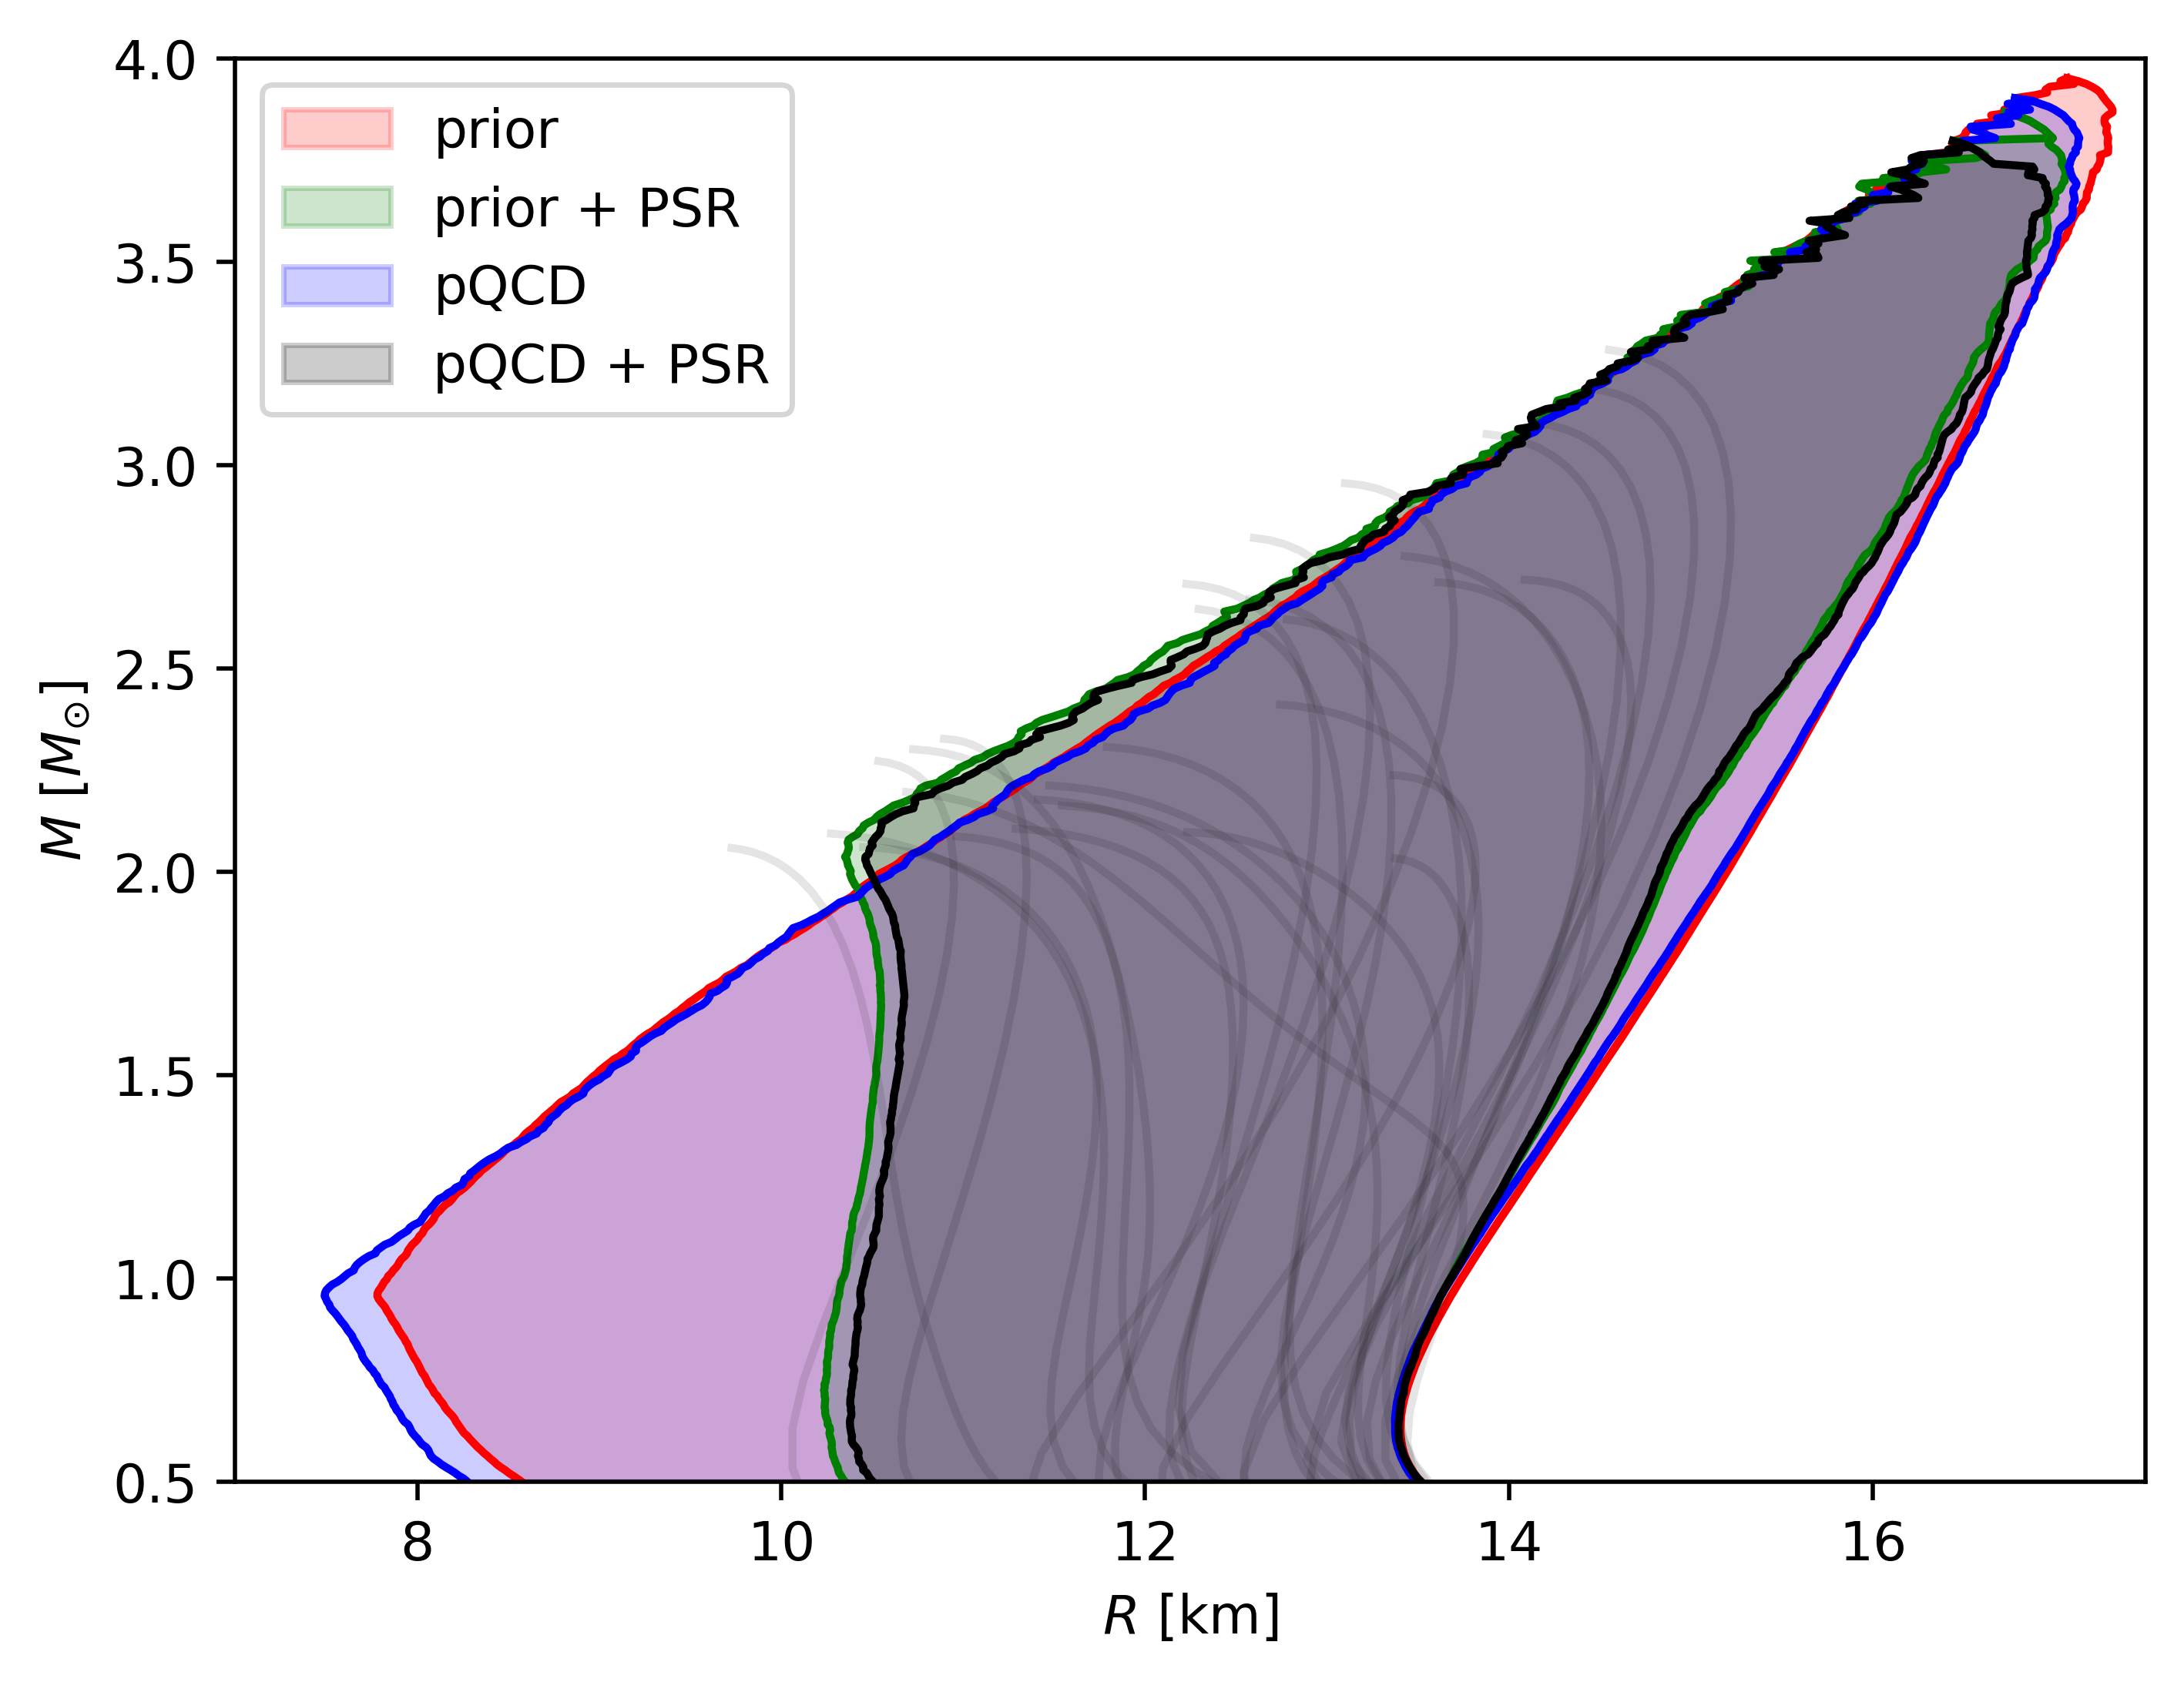

In [79]:
# Mass-radius contour
plt.xlabel(r"$R$ $\left[\mathrm{km}\right]$");
plt.ylabel(r"$M$ $\left[M_{\odot}\right]$");
plt.xlim(7, 17.5);
plt.ylim(0.5, 4.0);

plt.fill_betweenx(plot_masses,
                  prior_mr_quantiles[:, 0],
                  prior_mr_quantiles[:, 1],
                  alpha = 0.2,
                  color = "red",
                  label = "prior"
                 )

plt.fill_betweenx(plot_masses,
                  prior_psr_mr_quantiles[:, 0],
                  prior_psr_mr_quantiles[:, 1],
                  alpha = 0.2,
                  color = "green",
                  label = "prior + PSR"
                 )

plt.fill_betweenx(plot_masses,
                  conformal_mr_quantiles[:, 0],
                  conformal_mr_quantiles[:, 1],
                  alpha = 0.2,
                  color = "blue",
                  label = "pQCD"
                 )

plt.fill_betweenx(plot_masses,
                  conformal_psr_mr_quantiles[:, 0],
                  conformal_psr_mr_quantiles[:, 1],
                  alpha = 0.2,
                  color = "black",
                  label = "pQCD + PSR"
                 )

plt.plot(prior_mr_quantiles,
         plot_masses,
         color = "red"
        );

plt.plot(prior_psr_mr_quantiles,
         plot_masses,
         color = "green"
        );

plt.plot(conformal_mr_quantiles,
         plot_masses,
         color = "blue"
        );

plt.plot(conformal_psr_mr_quantiles,
         plot_masses,
         color = "black"
        );

# Plotting example draws of conformal EoS
with h5py.File(conformal_h5_path) as h5_file:
    ns_data = h5_file["ns"]
    for i in range(30):
        sample = np.random.randint(0, len(weighted_conformal_eoss))
        weight_index = weighted_conformal_eoss[sample]
        sample_key = f"eos_{conformal_eos_indices[weight_index]:06d}"
        mass = ns_data[sample_key]["M"]
        radius = ns_data[sample_key]["R"]
        plt.plot(radius, mass, color = "black", alpha = 0.1);

    h5_file.close()

plt.gcf().set_dpi(500)
plt.legend();

# Saving plot        
plot_folder = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/plots"
plt.savefig(f"{plot_folder}/mr_PSR_0.jpg", bbox_inches = "tight");
plt.savefig(f"{plot_folder}/mr_PSR_J0348_0.pdf", bbox_inches = "tight");